## Substantia Nigra Neuronal Subtyping Report 
This notebook summarizes preprocessing, integration, subtyping, and visualization for substantia nigra (SN) single‑cell dataset. It includes QC, embeddings, subtype discovery, and aggregated expression summaries.


### Set Up Environment

In [1]:
#set up conda environment 
# in a terminal
# conda env create -f environment.yml
# conda init 
## restart terminal
# conda activate scvi-cells
# python -m ipykernel install --user --name=scvi-cells --display-name "Python (scvi-cells)"

In [2]:
import scvi, pandas as pd, numpy as np, scanpy as sc,  seaborn as sns, matplotlib.pyplot as plt
import sys, subprocess, importlib, warnings, math, os
from pathlib import Path

try:
    %load_ext autotime
except ModuleNotFoundError:
    %pip install ipython-autotime
    %load_ext autotime

/opt/conda/envs/scvi-cells/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


time: 166 μs (started: 2026-01-08 22:30:00 +00:00)


## 1. Workspace Setup

### 1.1 Set dataset paths
In this example, we are working with the **PMDBS single‑cell RNA‑seq cohort** dataset:

- **Workflow** → `pmdbs_sc_rnaseq`  
- **Team** → `cohort`  
- **Source** → `pmdbs`  
- **Type** → `sc-rnaseq`  

These components are combined to construct the bucket and dataset names.  
We then set the path to the **cohort analysis outputs** and preview the available files.


In [3]:
#set general folder paths
HOME = Path.home()
WS_ROOT = HOME / "workspace"
DATA_DIR = WS_ROOT / "Data"
WS_FILES = WS_ROOT / "ws_files"

if not WS_ROOT.exists():
    print(f"{WS_ROOT} doesn't exist. We need to remount our resources")
    !wb resource mount    

print("Home directory:     ", HOME)
print("Workspace root:     ", WS_ROOT)
print("Data directory:     ", DATA_DIR)
print("ws_files directory: ", WS_FILES)

print("\nContents of workspace root:")
for p in WS_ROOT.glob("*"):
    print(" -", p.name, "/" if p.is_dir() else "")

Home directory:      /home/jupyter
Workspace root:      /home/jupyter/workspace
Data directory:      /home/jupyter/workspace/Data
ws_files directory:  /home/jupyter/workspace/ws_files

Contents of workspace root:
 - Documentation /
 - ws_files /
 - 10_Other /
 - 02_Mouse /
 - 01_PMDBS /
 - release_resources /
time: 6.07 ms (started: 2026-01-08 22:30:00 +00:00)


In [4]:
## Build and set path to desired dataset

DATASETS_PATH = WS_ROOT / "01_PMDBS_scRNAseq"

workflow       = "pmdbs_sc_rnaseq"
dataset_team   = "cohort"
dataset_source = "pmdbs"
dataset_type   = "sc-rnaseq"

bucket_name  = f"asap-curated-{dataset_team}-{dataset_source}-{dataset_type}"
dataset_name = f"asap-{dataset_team}-{dataset_source}-{dataset_type}"

dataset_path = DATASETS_PATH / bucket_name / workflow
print("Dataset Path:", dataset_path)

# Build the folder path to the cohort analysis directory
cohort_analysis_path = dataset_path / "cohort_analysis"

# Preview the directory contents
print("Contents of cohort_analysis:")
!ls {cohort_analysis_path}

Dataset Path: /home/jupyter/workspace/01_PMDBS_scRNAseq/asap-curated-cohort-pmdbs-sc-rnaseq/pmdbs_sc_rnaseq
Contents of cohort_analysis:
ls: cannot access '/home/jupyter/workspace/01_PMDBS_scRNAseq/asap-curated-cohort-pmdbs-sc-rnaseq/pmdbs_sc_rnaseq/cohort_analysis': No such file or directory
time: 1.15 s (started: 2026-01-08 22:30:00 +00:00)


In [5]:
# Define a local path for workshop files
local_data_path = WS_FILES / "case_study_01"

# map my cells directories
mapmycells_input_dir = ( local_data_path / "mapmycells/input" )
mapmycells_output_dir = ( local_data_path / "mapmycells/output" )

# other directories
resources_path =( local_data_path / "resources")
plots_path =( local_data_path / "output_plots")
output_path =( local_data_path / "output_matrices")

# Make sure the directories exists
os.makedirs(mapmycells_input_dir, exist_ok=True)
os.makedirs(mapmycells_output_dir, exist_ok=True)
os.makedirs(resources_path, exist_ok=True)
os.makedirs(output_path, exist_ok=True)
os.makedirs(plots_path, exist_ok=True)

# Create the directory if it doesn't already exist
if not local_data_path.exists():
    local_data_path.mkdir(parents=True)

print(f"Local data directory ready at: {local_data_path}")

Local data directory ready at: /home/jupyter/workspace/ws_files/case_study_01
time: 272 ms (started: 2026-01-08 22:30:01 +00:00)


### 1.2 Copy Data Locally

- **`asap-cohort.final_metadata.csv`** → cell‑level metadata table
- **`asap-cohort.final.h5ad`** → full AnnData object containing HVG expression data and annotations  

In [6]:
# Downloading obs field (cell metadata)
# Define the expected local path for the metadata file.
cell_metadata_local_path = local_data_path / f"asap-{dataset_team}.final_metadata.csv"\

# Check if the metadata file already exists locally.
if not cell_metadata_local_path.exists():
    # Construct the original path where the metadata file is stored.
    cell_metadata_og_path = cohort_analysis_path / f"asap-{dataset_team}.final_metadata.csv"

    # Use a shell command (`cp`) to copy the file from the original location
    # into the local workshop_files directory for analysis.
    !cp {cell_metadata_og_path} {cell_metadata_local_path}

time: 20.7 ms (started: 2026-01-05 21:43:44 +00:00)


In [7]:
# Downloading the anndata object
# Define the expected local path
adata_local_path = local_data_path / f"asap-{dataset_team}.final.h5ad"

# Check if the adata file already exists locally.
if not adata_local_path.exists():
    # Construct the original path where the metadata file is stored.
    adata_cell_metadata_og_path = cohort_analysis_path / f"asap-{dataset_team}.final.h5ad"

    # Use a shell command (`cp`) to copy the file from the original location
    # into the local workshop_files directory for analysis.
    !cp {adata_cell_metadata_og_path} {adata_local_path}

# load the adata object
adata = sc.read_h5ad(adata_local_path, backed="r")
adata

AnnData object with n_obs × n_vars = 3046127 × 3000 backed at '/home/jupyter/workspace/ws_files/case_study_01/asap-cohort.final.h5ad'
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'total_counts', 'total_counts_rb', 'pct_counts_rb', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'sample', 'batch', 'team', 'dataset', 'batch_id', 'S_score', 'G2M_score', 'phase', 'cell_type', 'phenotype', 'rho', 'prob', 'class_name', 'subclass_name', 'supertype_name', '_scvi_batch', '_scvi_labels', 'C_scANVI', 'leiden_res_0.05', 'leiden_res_0.10', 'leiden_res_0.20', 'leiden_res_0.40'
    var: 'feature_type', 'genome', 'gene_id', 'mt', 'rb'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'estimator', 'fraction_data_used_for_testing', 'learning_curve_learning_rate_epoch', 'learning_curve_test_epoch', 'learning_curve_train_epoch', 'leiden_res_0.05', 'leiden_res_0.10', 'leiden_res_0.20', 'leiden_res_0.40', 'log1p', 'neighbors', 'pca', 'scrublet',

time: 9min 45s (started: 2026-01-05 21:43:45 +00:00)


### 1.3 Metadata Access & Integration 

In [8]:
#Define metadata folder path
ds_metadata_path = WS_ROOT / "release_resources/cohort-pmdbs-sc-rnaseq/metadata"

#preview contents
!ls {ds_metadata_path} 

ASSAY_RNAseq.csv  collection_version  PMDBS.csv     STUDY.csv
cde_version	  CONDITION.csv       PROTOCOL.csv  SUBJECT.csv
CLINPATH.csv	  DATA.csv	      SAMPLE.csv
time: 1.25 s (started: 2026-01-05 21:53:31 +00:00)


In [9]:
# study-level metadata
STUDY = pd.read_csv(ds_metadata_path / "STUDY.csv", index_col = 0)
STUDY[["ASAP_team_id" , "dataset_name","sample_types"]]

#definitely team Lee

,ASAP_team_id,dataset_name,sample_types
0,TEAM_HAFLER,Single-cell transcriptomic and proteomic analy...,Prefrontal cortex
1,TEAM_LEE,Single nucleus RNA-sequencing of human postmor...,hippocampus; middle frontal gyrus; substantia ...
2,TEAM_SCHERZER,MTG_snRNAseq,MTG
3,TEAM_HARDY,Single-nucleus RNA sequencing of human post-mo...,"Inferior Parietal Lobule (IPL), Anterior Cingu..."
4,TEAM_JAKOBSSON,NaN,sc-rnaseq
5,TEAM_SULZER,Single-nucleus RNAseq of the post-mortem cingu...,Cingulate Cortex and Substantia nigra


time: 339 ms (started: 2026-01-05 21:53:32 +00:00)


In [10]:
# Sample-level metadata
SAMPLE = pd.read_csv(ds_metadata_path / "SAMPLE.csv", index_col=0)
# Subject-level metadata
SUBJECT = pd.read_csv(ds_metadata_path / "SUBJECT.csv", index_col=0)
#  Brain-sample metadata
PMDBS = pd.read_csv(ds_metadata_path / "PMDBS.csv", index_col=0)
# Experimental condition metadata
CONDITION = pd.read_csv(ds_metadata_path / "CONDITION.csv", index_col=0)

# Select Relevant Columns
sample_cols = [
    "ASAP_sample_id",
    "ASAP_subject_id",
    "ASAP_team_id",
    "ASAP_dataset_id",
     "subject_id",
    "replicate",
    "condition_id",
    "age_at_collection"
]
subject_cols = [
    "ASAP_dataset_id",
    "ASAP_subject_id",
    "subject_id",
    "source_subject_id",
    "sex",
    "biobank_name",
    "primary_diagnosis",
]
pmdbs_cols = [
    "ASAP_sample_id",
    "brain_region",
    "region_level_1",
    "region_level_2",
    "region_level_3",
]
condition_cols = [
    "ASAP_team_id",
    "ASAP_dataset_id",
    "condition_id",
    "intervention_name",
    "intervention_id",
    "protocol_id",
]

time: 377 ms (started: 2026-01-05 21:53:32 +00:00)


## 2. Data Assessment

### 2.1 Evaluating datasets with SN region specfificty

Relevant datasets:
- Team Lee
- Team Jakobsson

In [11]:
print("SAMPLE cols: \n", SAMPLE.columns, "\n", "\n SUBJECT cols: \n",
      SUBJECT.columns,  "\n", " \n CONDITION cols: \n", CONDITION.columns, "\n", "\n  PMDBS cols: \n", PMDBS.columns)

SAMPLE cols: 
 Index(['ASAP_team_id', 'ASAP_dataset_id', 'ASAP_sample_id', 'ASAP_subject_id',
       'sample_id', 'subject_id', 'source_sample_id', 'replicate',
       'replicate_count', 'repeated_sample', 'batch', 'organism', 'tissue',
       'assay_type', 'condition_id', 'organism_ontology_term_id',
       'age_at_collection', 'time', 'alternate_id',
       'development_stage_ontology_term_id', 'sex_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id',
       'tissue_ontology_term_id', 'assay_ontology_term_id', 'donor_id',
       'pm_PH', 'cell_type_ontology_term_id', 'source_RIN', 'DV200',
       'suspension_type'],
      dtype='object') 
 
 SUBJECT cols: 
 Index(['ASAP_team_id', 'ASAP_dataset_id', 'ASAP_subject_id', 'subject_id',
       'source_subject_id', 'biobank_name', 'sex', 'race', 'primary_diagnosis',
       'gp2_phenotype', 'primary_diagnosis_text'],
      dtype='object') 
  
 CONDITION cols: 
 Index(['ASAP_team_id', 'ASAP_dataset

In [12]:
PMDBS[["ASAP_team_id","region_level_2"]].value_counts()

ASAP_team_id    region_level_2          
TEAM_SCHERZER   Middle temporal gyrus       97
TEAM_HARDY      Anterior cingulate gyrus    64
                Inferior parietal lobule    64
TEAM_JAKOBSSON  Putamen                     37
                Amygdala                    34
                Substantia nigra            34
TEAM_SULZER     Substantia nigra            27
TEAM_LEE        CA1-CA4                     25
                Middle frontal gyrus        25
                Substantia nigra            25
TEAM_JAKOBSSON  Prefrontal cortex           20
TEAM_HAFLER     Prefrontal cortex           12
Name: count, dtype: int64

time: 92.2 ms (started: 2026-01-05 21:55:55 +00:00)


In [13]:
#validating sample ID is unique
PMDBS.duplicated(subset="ASAP_sample_id").sum()
print(len(PMDBS[PMDBS["region_level_2"]== "Substantia nigra"]), "SN samples out of" ,len(PMDBS), "total samples")

86 SN samples out of 504 total samples
time: 2.75 ms (started: 2026-01-05 21:55:55 +00:00)


In [14]:
#some scherzer sample have NA for condition but filled intervention_id 
CONDITION["condition_id"] = CONDITION["condition_id"].fillna(CONDITION["intervention_id"])

time: 1.76 ms (started: 2026-01-05 21:55:56 +00:00)


In [15]:

df = pd.merge(
    SAMPLE[sample_cols],
    CONDITION[condition_cols],
    on=["ASAP_dataset_id","ASAP_team_id", "condition_id"],
    how="left",          # keep all SAMPLE rows, add CONDITION info
    validate="many_to_many"  # each SAMPLE row maps to one CONDITION row
)

df = pd.merge(
    df,
    SUBJECT[subject_cols],
    on=["ASAP_subject_id", "ASAP_dataset_id", "subject_id"],
    how="left",          # keep all SAMPLE rows, add SUBJECT info
    validate="many_to_many"  # each SUBJECT row maps to multiple SAMPLE rows
)

# Merge in brain-region information
df = pd.merge(df, 
              PMDBS[pmdbs_cols], 
              on=["ASAP_sample_id"], 
              how="left", 
              validate = "many_to_many" )

# create unique sample identifier
df["sample"] = df["ASAP_sample_id"] + "_" + df["replicate"]


time: 135 ms (started: 2026-01-05 21:55:56 +00:00)


In [16]:
df.head()

,ASAP_sample_id,ASAP_subject_id,ASAP_team_id,ASAP_dataset_id,subject_id,replicate,condition_id,age_at_collection,intervention_name,intervention_id,protocol_id,source_subject_id,sex,biobank_name,primary_diagnosis,brain_region,region_level_1,region_level_2,region_level_3,sample
0,ASAP_PMBDS_000026_s001,ASAP_PMBDS_000026,TEAM_HAFLER,DS_PMDBS_0002,HC01,Rep1,Control,81.0,Case-Control,NaN,NaN,hSDG07,Female,NKI/NYUGSOM,Healthy Control,Prefrontal Cortex,Frontal lobe,Prefrontal cortex,Grey matter,ASAP_PMBDS_000026_s001_Rep1
1,ASAP_PMBDS_000027_s001,ASAP_PMBDS_000027,TEAM_HAFLER,DS_PMDBS_0002,HC02,Rep1,Control,65.0,Case-Control,NaN,NaN,hSDG13,Female,NKI/NYUGSOM,Healthy Control,Prefrontal Cortex,Frontal lobe,Prefrontal cortex,Grey matter,ASAP_PMBDS_000027_s001_Rep1
2,ASAP_PMBDS_000028_s001,ASAP_PMBDS_000028,TEAM_HAFLER,DS_PMDBS_0002,HC03,Rep1,Control,72.0,Case-Control,NaN,NaN,hSDG101,Female,NKI/NYUGSOM,Healthy Control,Prefrontal Cortex,Frontal lobe,Prefrontal cortex,Grey matter,ASAP_PMBDS_000028_s001_Rep1
3,ASAP_PMBDS_000029_s001,ASAP_PMBDS_000029,TEAM_HAFLER,DS_PMDBS_0002,HC04,Rep1,Control,70.0,Case-Control,NaN,NaN,hSDG10,Male,NKI/NYUGSOM,Healthy Control,Prefrontal Cortex,Frontal lobe,Prefrontal cortex,Grey matter,ASAP_PMBDS_000029_s001_Rep1
4,ASAP_PMBDS_000030_s001,ASAP_PMBDS_000030,TEAM_HAFLER,DS_PMDBS_0002,HC05,Rep1,Control,63.0,Case-Control,NaN,NaN,hSDG30,Male,NKI/NYUGSOM,Healthy Control,Prefrontal Cortex,Frontal lobe,Prefrontal cortex,Grey matter,ASAP_PMBDS_000030_s001_Rep1


time: 18 ms (started: 2026-01-05 21:55:57 +00:00)


In [17]:
df[["ASAP_team_id","brain_region", "region_level_2"]].value_counts()
#why does team lee have substantia nigra and MFG associated with the same sample

ASAP_team_id    brain_region           region_level_2          
TEAM_SCHERZER   Middle temporal gyrus  Middle temporal gyrus       97
TEAM_HARDY      IPL                    Inferior parietal lobule    71
                ACG                    Anterior cingulate gyrus    67
TEAM_JAKOBSSON  Putamen                Putamen                     37
                Amygdala               Amygdala                    34
                Substantia nigra       Substantia nigra            34
TEAM_SULZER     Substantia Nigra       Substantia nigra            28
TEAM_LEE        Hippocampus            CA1-CA4                     25
                Middle frontal gyrus   Middle frontal gyrus        25
                Substantia nigra       Substantia nigra            25
TEAM_JAKOBSSON  Prefrontal cortex      Prefrontal cortex           20
TEAM_HAFLER     Prefrontal Cortex      Prefrontal cortex           12
Name: count, dtype: int64

time: 9.87 ms (started: 2026-01-05 21:55:57 +00:00)


In [18]:
# Recode brain region to be "PFC", "MFG", "HIP", "SN", "ACG", "IPL, "AMG", "PUT"
brain_fix = {
    "Prefrontal Cortex": "PFC",
    "Middle_Frontal_Gyrus": "MFG",
    "Hippocampus": "HIP",
    "Substantia_Nigra ": "SN",
    "ACG": "ACG",
    "IPL": "IPL",
    "Middle temporal gyrus": "MTG",
    "Substantia nigra": "SN",
    "Prefrontal cortex": "PFC",
    "Amygdala": "AMG",
    "Putamen": "PUT",
}
df["brain_region"] = df["brain_region"].map(brain_fix)

time: 2.35 ms (started: 2026-01-05 21:55:58 +00:00)


In [19]:
# Map to find more course designations
brain_simple = {
    "PFC": "frontal_ctx",
    "MFG": "frontal_ctx",
    "ACG": "cingulate_ctx",
    "IPL": "parietal_ctx",
    "MTG": "temporal_ctx",
    "HIP": "subcortical",
    "AMG": "subcortical",
    "PUT": "subcortical",
    "SN": "subcortical",
}

df["brain_region_simple"] = df["brain_region"].map(brain_simple)


# Define sample to match
br_mapper_full = dict(zip(df["sample"], df["brain_region"]))
br_mapper_simple = dict(zip(df["sample"], df["brain_region"].map(brain_simple)))

# Parkinsons and control samples
condition_id_mapper = dict(zip(df["sample"], df["condition_id"]))
case_id_mapper = dict(zip(df["sample"], df["intervention_name"]))

# Detailed brain region mapper 
region_1_mapper = dict(zip(df["sample"], df["region_level_1"]))
region_2_mapper = dict(zip(df["sample"], df["region_level_2"]))

# Diagnoses
diagnoses_mapper = dict(zip(df["sample"], df["primary_diagnosis"]))

#dataset metadata
dataset_mapper = dict(zip(df["sample"], df["ASAP_dataset_id"]))
biobank_mapper = dict(zip(df["sample"], df["biobank_name"]))

time: 5.42 ms (started: 2026-01-05 21:55:58 +00:00)


In [20]:
dataset_metadata_filen = local_data_path / "asap-cohort-dataset-metadata.csv"
df.to_csv(dataset_metadata_filen)

time: 354 ms (started: 2026-01-05 21:55:59 +00:00)


In [21]:
df[df["region_level_2"] == "Substantia nigra"][["ASAP_team_id", "ASAP_dataset_id"]].value_counts()

ASAP_team_id    ASAP_dataset_id
TEAM_JAKOBSSON  DS_PMDBS_0004      34
TEAM_SULZER     DS_PMDBS_0006      28
TEAM_LEE        DS_PMDBS_0001      25
Name: count, dtype: int64

time: 8.75 ms (started: 2026-01-05 21:55:59 +00:00)


In [22]:
df[df["region_level_2"] == "Substantia nigra"][["ASAP_team_id", "biobank_name"]].value_counts()

ASAP_team_id    biobank_name                        
TEAM_JAKOBSSON  Cambridge Brain Bank                    34
TEAM_SULZER     New York Brain Bank                     28
TEAM_LEE        Banner Sun Health Research Institute    25
Name: count, dtype: int64

time: 9.53 ms (started: 2026-01-05 21:56:00 +00:00)


In [23]:
# Map samples to metadata
adata.obs["brain_region"] = adata.obs["sample"].map(br_mapper_full)
adata.obs["brain_region_simple"] = adata.obs["sample"].map(br_mapper_simple)
adata.obs["case_id"] = adata.obs["sample"].map(case_id_mapper)
adata.obs["condition_id"] = adata.obs["sample"].map(condition_id_mapper)
adata.obs["region_level_1"] = adata.obs["sample"].map(region_1_mapper)
adata.obs["region_level_2"] = adata.obs["sample"].map(region_2_mapper)
adata.obs["dataset_id"] = adata.obs["sample"].map(dataset_mapper)
adata.obs["biobank_name"] = adata.obs["sample"].map(biobank_mapper)

time: 839 ms (started: 2026-01-05 21:56:00 +00:00)


### 2.3 Subset to cells within Substantia Nigra (SN) region

In [24]:
# identify substantia nigra cells
sn_cells = adata.obs["region_level_2"] == "Substantia nigra"
# Final boolean mask for subsetting
include = sn_cells
print(sn_cells.sum())

258505
time: 212 ms (started: 2026-01-05 21:56:04 +00:00)


In [25]:
# Create SN subset
sn_ad = adata[include].to_memory()
adata.file.close()  # close the original adata file

time: 17.2 s (started: 2026-01-05 21:56:04 +00:00)


In [26]:
sn_ad.obs[["dataset_id", "biobank_name", "condition_id", "region_level_2"]].value_counts()

dataset_id     biobank_name                          condition_id  region_level_2  
DS_PMDBS_0001  Banner Sun Health Research Institute  PD            Substantia nigra    80164
DS_PMDBS_0004  Cambridge Brain Bank                  Control       Substantia nigra    71928
DS_PMDBS_0001  Banner Sun Health Research Institute  Control       Substantia nigra    53637
DS_PMDBS_0004  Cambridge Brain Bank                  PD            Substantia nigra    52776
Name: count, dtype: int64

time: 93.8 ms (started: 2026-01-05 21:56:21 +00:00)


In [27]:
sn_ad.obs[["class_name"]].value_counts()

class_name                 
Non-neuronal and Non-neural    221589
Neuronal: GABAergic             31253
Neuronal: Glutamatergic          5663
Name: count, dtype: int64

time: 9.96 ms (started: 2026-01-05 21:56:22 +00:00)


### 2.3 Export SN subset (HVG)

In [28]:
sn_samples_filename = (
    local_data_path / f"asap-{dataset_team}.sn_samples_HVGonly.h5ad"
)
sn_ad.write_h5ad(sn_samples_filename)



time: 36.6 s (started: 2026-01-05 21:56:22 +00:00)


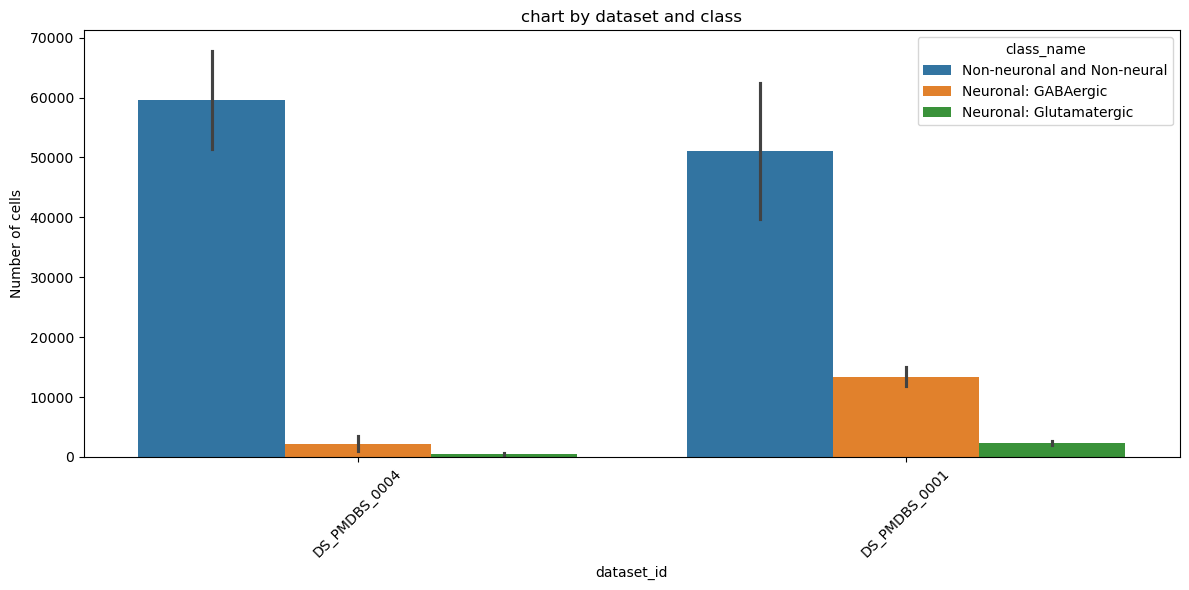

time: 1.58 s (started: 2026-01-05 21:56:58 +00:00)


In [29]:
df = sn_ad.obs[["dataset_id","class_name","condition_id"]].astype(str)

# Count occurrences of each combination
count_df = df.value_counts().reset_index(name="count")

plt.figure(figsize=(12,6))
sns.barplot(
    data=count_df,
    x="dataset_id",
    y="count",
    hue="class_name"
)
plt.xticks(rotation=45)
plt.ylabel("Number of cells")
plt.title("chart by dataset and class")
plt.tight_layout()
plt.show()


keeping PD and healthy together for now due to little number of neuronal cells

In [30]:
sn_ad.obs["cell_type"].value_counts()

cell_type
Oligodendrocyte    107844
Unknown            106570
Microglia-PVM       13588
Astrocyte           10465
OPC                  9038
Endothelial          4310
GABAergic            3976
VLMC                 2300
Glutamatergic         414
Name: count, dtype: int64

time: 8.09 ms (started: 2026-01-05 21:57:00 +00:00)


## 3. Data processing

### 3.1 Load Full Gene Expression for the SN Subset

In [31]:
# Define file paths 
full_adata_filename = (
    cohort_analysis_path / f"asap-{dataset_team}.merged_cleaned_unfiltered.h5ad"
)
l_full_adata_filename = (
    local_data_path / f"asap-{dataset_team}.merged_cleaned_unfiltered.h5ad"
)

if not l_full_adata_filename.exists():
    !cp {full_adata_filename} {l_full_adata_filename}

time: 45 ms (started: 2026-01-05 21:57:00 +00:00)


In [32]:
# Load full expression matrix
full_adata = sc.read_h5ad(l_full_adata_filename, backed="r")

time: 7min 52s (started: 2026-01-05 21:57:00 +00:00)


In [33]:
# Extract and select neuronal_subset cells from complete gene expression matrix
var_ = full_adata.var.copy()
X = full_adata[sn_ad.obs_names].X.copy()

full_adata.file.close()

time: 2min 22s (started: 2026-01-05 22:04:53 +00:00)


combine the full gene expression matrix with our substantia nigra neuron subset, and save the resulting AnnDataobject.

In [34]:
sn_full_ad = sc.AnnData(
    X=X,
    obs=sn_ad.obs,
    var=var_,
    uns=sn_ad.uns,
    obsm=sn_ad.obsm,
)
sn_full_ad

AnnData object with n_obs × n_vars = 258505 × 36601
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'total_counts', 'total_counts_rb', 'pct_counts_rb', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'sample', 'batch', 'team', 'dataset', 'batch_id', 'S_score', 'G2M_score', 'phase', 'cell_type', 'phenotype', 'rho', 'prob', 'class_name', 'subclass_name', 'supertype_name', '_scvi_batch', '_scvi_labels', 'C_scANVI', 'leiden_res_0.05', 'leiden_res_0.10', 'leiden_res_0.20', 'leiden_res_0.40', 'brain_region', 'brain_region_simple', 'case_id', 'condition_id', 'region_level_1', 'region_level_2', 'dataset_id', 'biobank_name'
    var: 'feature_type', 'genome', 'gene_id', 'mt', 'rb'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'estimator', 'fraction_data_used_for_testing', 'learning_curve_learning_rate_epoch', 'learning_curve_test_epoch', 'learning_curve_train_epoch', 'leiden_res_0.05', 'leiden_res_0.10', 'leiden_res_0.20', 'leiden_r

time: 14.5 ms (started: 2026-01-05 22:07:15 +00:00)


In [35]:
# Save full sn neuronal Anndata object
sn_full_samples_filename = (
    local_data_path / f"asap-{dataset_team}.sn_ad.h5ad"
)
sn_full_ad.write_h5ad(sn_full_samples_filename)

time: 2min 12s (started: 2026-01-05 22:07:15 +00:00)


### 3.2 MapMyCells with Human Basal Ganglia Taxonomy 

For more informations please see:
    https://alleninstitute.github.io/abc_atlas_access/descriptions/HMBA-BG_dataset.html

In [6]:
#if starting from here  ( RECOMMENDED FOR MEMORY)
sn_full_samples_filename = (
   local_data_path / f"asap-{dataset_team}.sn_ad.h5ad"
)
sn_full_ad = sc.read_h5ad(sn_full_samples_filename)

time: 2min 53s (started: 2026-01-05 22:37:40 +00:00)


In [7]:
sn_full_ad

AnnData object with n_obs × n_vars = 258505 × 36601
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'total_counts', 'total_counts_rb', 'pct_counts_rb', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'sample', 'batch', 'team', 'dataset', 'batch_id', 'S_score', 'G2M_score', 'phase', 'cell_type', 'phenotype', 'rho', 'prob', 'class_name', 'subclass_name', 'supertype_name', '_scvi_batch', '_scvi_labels', 'C_scANVI', 'leiden_res_0.05', 'leiden_res_0.10', 'leiden_res_0.20', 'leiden_res_0.40', 'brain_region', 'brain_region_simple', 'case_id', 'condition_id', 'region_level_1', 'region_level_2', 'dataset_id', 'biobank_name'
    var: 'feature_type', 'genome', 'gene_id', 'mt', 'rb'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'estimator', 'fraction_data_used_for_testing', 'learning_curve_learning_rate_epoch', 'learning_curve_test_epoch', 'learning_curve_train_epoch', 'leiden_res_0.05', 'leiden_res_0.10', 'leiden_res_0.20', 'leiden_r

time: 8.47 ms (started: 2026-01-05 22:40:33 +00:00)


In [8]:
# Set paths
precomputed_stats_filepath = ( mapmycells_input_dir / "Human.precomputed_stats.20250507.h5" )
query_markers_filepath =  ( mapmycells_input_dir / "Human.query_markers.20250507.json" )

time: 776 μs (started: 2026-01-05 22:43:38 +00:00)


#### 3.3 Download the taxonomy files required by MapMyCells

In [9]:
# grab taxonomy files 
#! wget "https://released-taxonomies-802451596237-us-west-2.s3.us-west-2.amazonaws.com/HMBA/BasalGanglia/BICAN_05072025_pre-print_release/MapMyCells/Human.precomputed_stats.20250507.h5" -O {precomputed_stats_filepath}
#! wget "https://released-taxonomies-802451596237-us-west-2.s3.us-west-2.amazonaws.com/HMBA/BasalGanglia/BICAN_05072025_pre-print_release/MapMyCells/Human.query_markers.20250507.json" -O {query_markers_filepath}

time: 561 μs (started: 2026-01-05 22:43:39 +00:00)


In [10]:
import json
import cell_type_mapper
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache
from cell_type_mapper.cli.from_specified_markers import FromSpecifiedMarkersRunner

time: 5.13 s (started: 2026-01-05 22:43:41 +00:00)


### 3.4 Prepare data for MapMyCells 

This taxonomic data uses the ensemble gene annotation IDs, so have to make those accessible to the Mapmycells program 

In [11]:
# have to use ENSG ids for this mapmycells taxonomy
# prep data

# Preserve gene_name as a column
adata_mmc = sn_full_ad.copy()
adata_mmc.var["gene_name"] = adata_mmc.var.index

# 2. Set var_names to gene_id (ENSG IDs)
adata_mmc.var_names = adata_mmc.var["gene_id"].astype(str)

# 3. Ensure uniqueness
adata_mmc.var_names_make_unique()

# Quick check
print(adata_mmc.var.head())
print(adata_mmc.var_names[:5])

adata_mmc_filename = ( mapmycells_input_dir / "sn_mapmycells_input.h5ad" )
adata_mmc.write_h5ad(adata_mmc_filename)


                    feature_type  genome          gene_id     mt     rb  \
gene_id                                                                   
ENSG00000243485  Gene Expression  GRCh38  ENSG00000243485  False  False   
ENSG00000237613  Gene Expression  GRCh38  ENSG00000237613  False  False   
ENSG00000186092  Gene Expression  GRCh38  ENSG00000186092  False  False   
ENSG00000238009  Gene Expression  GRCh38  ENSG00000238009  False  False   
ENSG00000239945  Gene Expression  GRCh38  ENSG00000239945  False  False   

                   gene_name  
gene_id                       
ENSG00000243485  MIR1302-2HG  
ENSG00000237613      FAM138A  
ENSG00000186092        OR4F5  
ENSG00000238009   AL627309.1  
ENSG00000239945   AL627309.3  
Index(['ENSG00000243485', 'ENSG00000237613', 'ENSG00000186092',
       'ENSG00000238009', 'ENSG00000239945'],
      dtype='object', name='gene_id')
time: 2min (started: 2026-01-05 22:43:48 +00:00)


In [6]:
sn_full_ad.file.close()
adata_mmc_filename = ( mapmycells_input_dir / "sn_mapmycells_input.h5ad" )
adata_mmc = sc.read_h5ad(adata_mmc_filename)

time: 13 s (started: 2026-01-08 22:30:13 +00:00)


In [13]:
import os
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"


# paths to files where mapping output will be written
json_dst_path = str( mapmycells_output_dir / "human_sn_mapping.json") 
csv_dst_path = str( mapmycells_output_dir / "human_sn_neruons_mapping.csv")


config = {
    "query_path": str(adata_mmc_filename),
    "extended_result_path": json_dst_path,
    "csv_result_path": csv_dst_path,
    "verbose_csv": True,
    "query_markers": {
       "serialized_lookup":str(query_markers_filepath)
    },
    "precomputed_stats": {
        "path": str(precomputed_stats_filepath)
    },
    "type_assignment": {
        "n_processors": 4,
        "normalization": "raw",
        "bootstrap_factor": 0.5,
        "bootstrap_iteration": 100
    }
}

time: 1.54 ms (started: 2026-01-05 22:50:15 +00:00)


In [14]:
# run map my cells
runner = FromSpecifiedMarkersRunner(
    args=[],
    input_data=config
)
runner.run()

=== Running Hierarchical Mapping 1.5.2 with config ===
{
  "extended_result_path": "/home/jupyter/workspace/ws_files/case_study_01/mapmycells/output/human_sn_mapping.json",
  "nodes_to_drop": null,
  "precomputed_stats": {
    "log_level": "ERROR",
    "path": "/home/jupyter/workspace/ws_files/case_study_01/mapmycells/input/Human.precomputed_stats.20250507.h5"
  },
  "verbose_csv": true,
  "verbose_stdout": true,
  "flatten": false,
  "obsm_clobber": false,
  "csv_result_path": "/home/jupyter/workspace/ws_files/case_study_01/mapmycells/output/human_sn_neruons_mapping.csv",
  "query_markers": {
    "collapse_markers": false,
    "log_level": "ERROR",
    "serialized_lookup": "/home/jupyter/workspace/ws_files/case_study_01/mapmycells/input/Human.query_markers.20250507.json"
  },
  "obsm_key": null,
  "hdf5_result_path": null,
  "drop_level": null,
  "map_to_ensembl": false,
  "type_assignment": {
    "bootstrap_factor": 0.5,
    "bootstrap_iteration": 100,
    "normalization": "raw",
   

/opt/conda/envs/scvi-cells/lib/python3.10/site-packages/cell_type_mapper/taxonomy/utils.py:253: UserWarning: This taxonomy has no mapping from leaf_node -> rows in the cell by gene matrix
  warnings.warn("This taxonomy has no mapping from leaf_node -> rows "


BENCHMARK: spent 2.7761e-01 seconds creating query marker cache
Running CPU implementation of type assignment.
40000 of 258505 cells in 2.27e+00 min; predict 1.24e+01 min of 1.47e+01 min left
50000 of 258505 cells in 3.13e+00 min; predict 1.31e+01 min of 1.62e+01 min left
60000 of 258505 cells in 3.54e+00 min; predict 1.17e+01 min of 1.53e+01 min left
70000 of 258505 cells in 3.72e+00 min; predict 1.00e+01 min of 1.37e+01 min left
80000 of 258505 cells in 4.17e+00 min; predict 9.31e+00 min of 1.35e+01 min left
90000 of 258505 cells in 4.96e+00 min; predict 9.28e+00 min of 1.42e+01 min left
100000 of 258505 cells in 5.14e+00 min; predict 8.14e+00 min of 1.33e+01 min left
110000 of 258505 cells in 5.49e+00 min; predict 7.41e+00 min of 1.29e+01 min left
120000 of 258505 cells in 5.69e+00 min; predict 6.57e+00 min of 1.23e+01 min left
130000 of 258505 cells in 6.36e+00 min; predict 6.29e+00 min of 1.26e+01 min left
140000 of 258505 cells in 6.55e+00 min; predict 5.55e+00 min of 1.21e+01 mi

In [40]:
mmc_mapping_filename = ( mapmycells_output_dir / "human_sn_neruons_mapping.csv" )
mmc_output = pd.read_csv(mmc_mapping_filename, comment='#')
mmc_output.columns

Index(['cell_id', 'Neighborhood_label', 'Neighborhood_name',
       'Neighborhood_bootstrapping_probability',
       'Neighborhood_aggregate_probability',
       'Neighborhood_correlation_coefficient', 'Class_label', 'Class_name',
       'Class_bootstrapping_probability', 'Class_aggregate_probability',
       'Class_correlation_coefficient', 'Subclass_label', 'Subclass_name',
       'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability',
       'Subclass_correlation_coefficient', 'Group_label', 'Group_name',
       'Group_bootstrapping_probability', 'Group_aggregate_probability',
       'Group_correlation_coefficient', 'Cluster_label', 'Cluster_name',
       'Cluster_alias', 'Cluster_bootstrapping_probability',
       'Cluster_aggregate_probability', 'Cluster_correlation_coefficient'],
      dtype='object')

time: 2 s (started: 2026-01-08 22:37:40 +00:00)


## Rename MapMyCells classes to intuitive naming strategy

In [41]:


def summarize_mmc_results(mmc_results: pd.DataFrame, workflow_name: str):
    """
    Summarize MMC results for human, mouse, or basal ganglia workflows.

    Parameters
    ----------
    mmc_results : pd.DataFrame
        Input dataframe containing MMC outputs.
    workflow_name : str
        One of: "pmdbs_sc_rnaseq", "mouse_sc_rnaseq", "basal_ganglia".

    Returns
    -------
    pd.DataFrame
        Summary dataframe with standardized fields.
    """

    # ------------------------------------------------------------
    # pmdbs_sc_rnaseq
    # ------------------------------------------------------------
    if workflow_name == "pmdbs_sc_rnaseq":
        gabaergic = mmc_results["class_name"] == "Neuronal: GABAergic"
        glutamatergic = mmc_results["class_name"] == "Neuronal: Glutamatergic"
        non_neuronal = mmc_results["class_name"] == "Non-neuronal and Non-neural"

        mmc_results.loc[gabaergic, "phenotype"] = "GABAergic"
        mmc_results.loc[glutamatergic, "phenotype"] = "Glutamatergic"
        mmc_results.loc[non_neuronal, "phenotype"] = mmc_results.loc[
            non_neuronal, "subclass_name"
        ]

        mmc_results.loc[glutamatergic, "rho"] = mmc_results.loc[
            glutamatergic, "class_correlation_coefficient"
        ]
        mmc_results.loc[gabaergic, "rho"] = mmc_results.loc[
            gabaergic, "class_correlation_coefficient"
        ]
        mmc_results.loc[non_neuronal, "rho"] = mmc_results.loc[
            non_neuronal, "subclass_correlation_coefficient"
        ]

        mmc_results.loc[glutamatergic, "prob"] = mmc_results.loc[
            glutamatergic, "class_bootstrapping_probability"
        ]
        mmc_results.loc[gabaergic, "prob"] = mmc_results.loc[
            gabaergic, "class_bootstrapping_probability"
        ]
        mmc_results.loc[non_neuronal, "prob"] = mmc_results.loc[
            non_neuronal, "subclass_bootstrapping_probability"
        ]

        mmc_results["cell_type"] = mmc_results["phenotype"]

        # Confidence filtering
        mmc_results.loc[mmc_results["rho"] < 0.5, "cell_type"] = "Unknown"
        mmc_results.loc[mmc_results["prob"] < 0.5, "cell_type"] = "Unknown"

        return mmc_results[
            [
                "cell_id"
                "cell_type",
                "phenotype",
                "rho",
                "prob",
                "class_name",
                "subclass_name",
                "supertype_name",
            ]
        ]

    # ------------------------------------------------------------
    # mouse_sc_rnase
    # ------------------------------------------------------------
    elif workflow_name == "mouse_sc_rnaseq":
        gabaergic = mmc_results["class_name"].str.contains("GABA")
        glutamatergic = mmc_results["class_name"].str.contains("Glut")
        serotonergic = mmc_results["class_name"].str.contains("Sero")
        non_neuronal = ~(gabaergic | glutamatergic | serotonergic)

        mmc_results.loc[gabaergic, "phenotype"] = "GABAergic"
        mmc_results.loc[glutamatergic, "phenotype"] = "Glutamatergic"
        mmc_results.loc[serotonergic, "phenotype"] = "Serotonergic"
        mmc_results.loc[non_neuronal, "phenotype"] = mmc_results.loc[
            non_neuronal, "subclass_name"
        ]

        mmc_results.loc[glutamatergic, "rho"] = mmc_results.loc[
            glutamatergic, "class_correlation_coefficient"
        ]
        mmc_results.loc[gabaergic, "rho"] = mmc_results.loc[
            gabaergic, "class_correlation_coefficient"
        ]
        mmc_results.loc[serotonergic, "rho"] = mmc_results.loc[
            serotonergic, "class_correlation_coefficient"
        ]
        mmc_results.loc[non_neuronal, "rho"] = mmc_results.loc[
            non_neuronal, "subclass_correlation_coefficient"
        ]

        mmc_results.loc[glutamatergic, "prob"] = mmc_results.loc[
            glutamatergic, "class_bootstrapping_probability"
        ]
        mmc_results.loc[gabaergic, "prob"] = mmc_results.loc[
            gabaergic, "class_bootstrapping_probability"
        ]
        mmc_results.loc[serotonergic, "prob"] = mmc_results.loc[
            serotonergic, "class_bootstrapping_probability"
        ]
        mmc_results.loc[non_neuronal, "prob"] = mmc_results.loc[
            non_neuronal, "subclass_bootstrapping_probability"
        ]

        mmc_results["cell_type"] = mmc_results["phenotype"]

        mmc_results.loc[mmc_results["rho"] < 0.5, "cell_type"] = "Unknown"
        mmc_results.loc[mmc_results["prob"] < 0.5, "cell_type"] = "Unknown"

        return mmc_results[
            [
                "cell_type",
                "phenotype",
                "rho",
                "prob",
                "class_name",
                "subclass_name",
                "supertype_name",
                "cluster_name",
                "cluster_correlation_coefficient",
                "cluster_bootstrapping_probability",
            ]
        ]

    # ------------------------------------------------------------
    # BASAL GANGLIA
    # ------------------------------------------------------------
    elif workflow_name == "basal_ganglia":
        class_mapper = {
            "OPC-Oligo": "OPC-Oligo",
            "Astro-Epen": "Astrocyte",
            "Vascular": "Vascular",
            "Immune": "Immune",
            "F M Glut": "Glutamatergic",
            "M Dopa": "Dopaminergic",
            "CN CGE GABA": "GABAergic",
            "F M GABA": "GABAergic",
            "CN MGE GABA": "GABAergic",
            "CN LGE GABA": "GABAergic",
            "Cx GABA": "GABAergic",
            "CN GABA-Glut": "GABAergic",
        }

        mmc_results["phenotype"] = mmc_results["Class_name"].map(class_mapper)

        gabaergic = mmc_results["Class_name"] == "GABAergic"
        mmc_results["rho"] = mmc_results["Class_correlation_coefficient"]
        mmc_results.loc[gabaergic, "rho"] = mmc_results.loc[
            gabaergic, "Neighborhood_correlation_coefficient"
        ]

        mmc_results["prob"] = mmc_results["Class_bootstrapping_probability"]
        mmc_results.loc[gabaergic, "prob"] = mmc_results.loc[
            gabaergic, "Neighborhood_bootstrapping_probability"
        ]

        mmc_results["cell_type"] = mmc_results["phenotype"]
        mmc_results.loc[mmc_results["rho"] < 0.5, "cell_type"] = "Unknown"
        mmc_results.loc[mmc_results["prob"] < 0.5, "cell_type"] = "Unknown"

        name_mapper = {
            "Neighborhood_name": "supertype_name",
            "Class_name": "class_name",
            "Subclass_name": "subclass_name",
        }
        mmc_results.rename(columns=name_mapper, inplace=True)

        return mmc_results[
            [
                "cell_id",
                "cell_type",
                "phenotype",
                "rho",
                "prob",
                "class_name",
                "subclass_name",
                "supertype_name"
            ]
        ]

    # ------------------------------------------------------------
    # UNKNOWN WORKFLOW
    # ------------------------------------------------------------
    else:
        raise ValueError(
            f"[ERROR] Source cannot be detected from workflow name: [{workflow_name}]"
        )

time: 7.23 ms (started: 2026-01-08 22:37:42 +00:00)


In [42]:
mmc_res = summarize_mmc_results(mmc_output, "basal_ganglia")
mmc_res.head()

,cell_id,cell_type,phenotype,rho,prob,class_name,subclass_name,supertype_name
0,TCGGTAAGTGACTACT-1_ASAP_PMBDS_000001_s003_rep1...,OPC-Oligo,OPC-Oligo,0.8487,1.0,OPC-Oligo,Oligodendrocyte,Nonneuron
1,AGAGCTTTCTTCGAGA-1_ASAP_PMBDS_000001_s003_rep1...,OPC-Oligo,OPC-Oligo,0.8757,1.0,OPC-Oligo,Oligodendrocyte,Nonneuron
2,CCTCAGTGTCATCCCT-1_ASAP_PMBDS_000001_s003_rep1...,OPC-Oligo,OPC-Oligo,0.9023,1.0,OPC-Oligo,Oligodendrocyte,Nonneuron
3,GGGTTGCGTTGACGTT-1_ASAP_PMBDS_000001_s003_rep1...,OPC-Oligo,OPC-Oligo,0.8271,1.0,OPC-Oligo,Oligodendrocyte,Nonneuron
4,CATCGGGGTAACGCGA-1_ASAP_PMBDS_000001_s003_rep1...,OPC-Oligo,OPC-Oligo,0.9078,1.0,OPC-Oligo,Oligodendrocyte,Nonneuron


time: 91.1 ms (started: 2026-01-08 22:37:42 +00:00)


### 3.5 Assess Mapmycells results

In [44]:
# Set index to cell_id for easy alignment
mapmycells_df = mmc_res.set_index("cell_id")

# validate connection 
print(len(set(mapmycells_df.index).intersection(set(adata_mmc.obs_names))))

# assign directly 
for col in ["cell_type", "class_name", "subclass_name", "supertype_name", "phenotype", "rho", "prob"]: 
    adata_mmc.obs[col] = mapmycells_df[col].values


258505
time: 276 ms (started: 2026-01-08 22:37:42 +00:00)


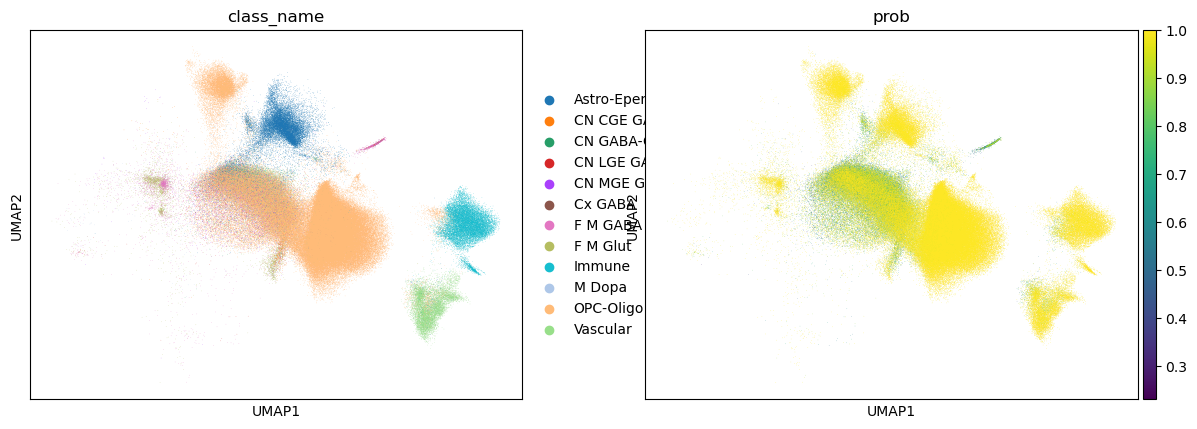

time: 3.23 s (started: 2026-01-08 22:39:24 +00:00)


In [47]:
sc.pl.umap(adata_mmc, color=["class_name", "prob"])

In [46]:
# move gene names back to index for readability
# 2. Set var_names to gene_names
adata_mmc.var_names = adata_mmc.var["gene_name"].astype(str)

# 3. Ensure uniqueness
adata_mmc.var_names_make_unique()

# Quick check
print(adata_mmc.var.head())
print(adata_mmc.var_names[:5])

mmc_adata_output_filepath = ( mapmycells_output_dir / "sn_mapmycells_integrated_output.h5ad")
adata_mmc.write_h5ad(mmc_adata_output_filepath)

                feature_type  genome          gene_id     mt     rb  \
gene_name                                                             
MIR1302-2HG  Gene Expression  GRCh38  ENSG00000243485  False  False   
FAM138A      Gene Expression  GRCh38  ENSG00000237613  False  False   
OR4F5        Gene Expression  GRCh38  ENSG00000186092  False  False   
AL627309.1   Gene Expression  GRCh38  ENSG00000238009  False  False   
AL627309.3   Gene Expression  GRCh38  ENSG00000239945  False  False   

               gene_name  
gene_name                 
MIR1302-2HG  MIR1302-2HG  
FAM138A          FAM138A  
OR4F5              OR4F5  
AL627309.1    AL627309.1  
AL627309.3    AL627309.3  
Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3'], dtype='object', name='gene_name')
time: 1min 38s (started: 2026-01-08 22:37:46 +00:00)


## 4. Data Processing & Analysis   

### 4.1 Data Processing
#### Steps:

    - Normalize 
    - Log transform 
    - Re-calculate HVG for SN region subset
    - Perform PCA
    - Calculate Neighbors using global scVI 
    - Leiden cluster

In [48]:
#if starting from here: 
# mmc_adata_output_filepath = ( 
#     mapmycells_output_dir / 
#     "sn_mapmycells_integrated_output.h5ad"
# )
# adata_mmc = sc.read_h5ad(mmc_adata_output_filepath)

time: 507 μs (started: 2026-01-08 22:40:43 +00:00)


In [49]:
# work on tmp copy
adata_neurons_tmp = adata_mmc.copy()
# keep raw in counts layer
adata_neurons_tmp.layers["counts"] = adata_neurons_tmp.X.copy() 

sc.pp.normalize_total(adata_neurons_tmp, target_sum=1e4)
sc.pp.log1p(adata_neurons_tmp)

# detect hvg of SN subset
hvgs_res =sc.experimental.pp.highly_variable_genes(
        adata_neurons_tmp,
        n_top_genes=3000,
        batch_key="sample", #using sample not batch
        flavor="pearson_residuals",
        check_values=True,
        layer="counts",
        subset=False,
        inplace=False
)

time: 1min 9s (started: 2026-01-08 22:40:47 +00:00)


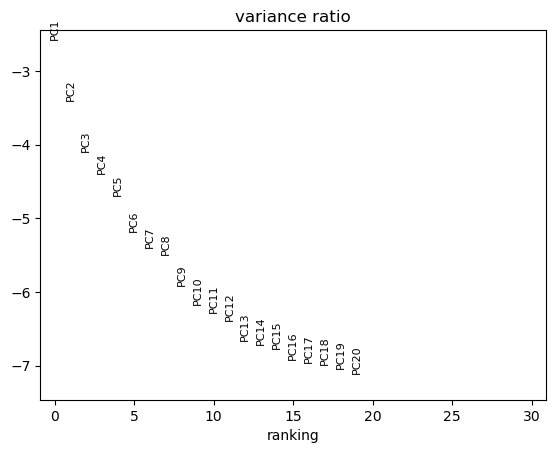

time: 3min 10s (started: 2026-01-08 22:41:56 +00:00)


In [50]:
# PCA for QC diagnostics
sc.tl.pca(adata_neurons_tmp, svd_solver="arpack", n_comps=20)
sc.pl.pca_variance_ratio(adata_neurons_tmp, log=True)

adata_neurons_tmp.obsm["X_scVI"] = adata_neurons_tmp.obsm["X_scVI"].astype("float32")
# Neighborhood graph using scVI embedding
sc.pp.neighbors(adata_neurons_tmp, use_rep="X_scVI", n_neighbors=30)

In [51]:
sc.tl.leiden(adata_neurons_tmp, resolution=1.0, key_added="leiden_sn_scVI_1.0", random_state=0)

/tmp/ipykernel_1553/2861327027.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_neurons_tmp, resolution=1.0, key_added="leiden_sn_scVI_1.0", random_state=0)


time: 9min 37s (started: 2026-01-08 22:45:07 +00:00)


### 4.2 DA marker analysis and scoring 

#### DA marker genes: 
- [TH](https://www.genecards.org/cgi-bin/carddisp.pl?gene=TH&keywords=TH)
- [DDC](https://www.genecards.org/cgi-bin/carddisp.pl?gene=DDC&keywords=DDC)
- [SLC6A3](https://www.genecards.org/cgi-bin/carddisp.pl?gene=SLC6A3&keywords=SLC6A3)
- [NR4A2](https://www.genecards.org/cgi-bin/carddisp.pl?gene=NR4A2)
- [SLC18A2](https://www.genecards.org/cgi-bin/carddisp.pl?gene=SLC18A2&keywords=SLC18A2)

Together, these genes capture three essential aspects of the dopamine neuron phenotype:
1. Dopamine synthesis — TH, DDC
2. Dopamine storage and synaptic handling — SLC6A3, SLC18A2
3. Transcriptional identity and maintenance — NR4A2

##### Resources: 
- [https://www.nature.com/articles/s41593-022-01061-1](https://www.nature.com/articles/s41593-022-01061-1)
- [https://www.cell.com/cell-reports/references/S2211-1247(14)00862-6](https://www.cell.com/cell-reports/references/S2211-1247(14)00862-6)
- [https://www.pnas.org/doi/10.1073/pnas.2410331121](https://www.pnas.org/doi/10.1073/pnas.2410331121)
- [https://pmc.ncbi.nlm.nih.gov/articles/PMC7285906/](https://pmc.ncbi.nlm.nih.gov/articles/PMC7285906/)
- [https://elifesciences.org/articles/101035#s2](https://elifesciences.org/articles/101035#s2)
- [https://www.science.org/doi/10.1126/sciadv.adi8287](https://www.science.org/doi/10.1126/sciadv.adi8287)


In [52]:
# validate presence of marker genes
marker_genes = ["TH", "DDC", "SLC6A3", "NR4A2", "SLC18A2"]
for g in marker_genes:
    assert g in adata_neurons_tmp.var_names, f"{g} not found in var_names!"
existing_markers = [g for g in marker_genes if g in adata_neurons_tmp.var_names]
# Score DA neuron markers
sc.tl.score_genes(adata_neurons_tmp, existing_markers, score_name="DA_score")

time: 5.4 s (started: 2026-01-08 22:54:44 +00:00)


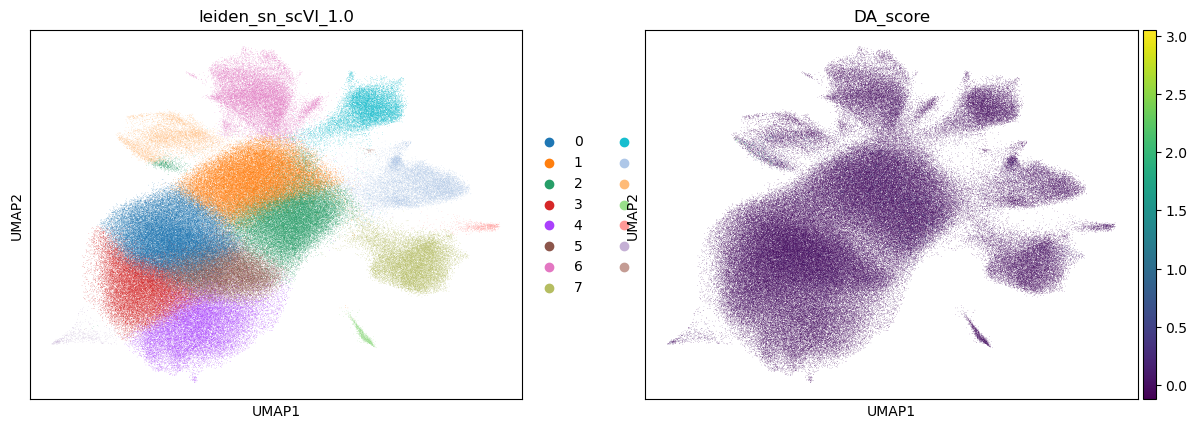

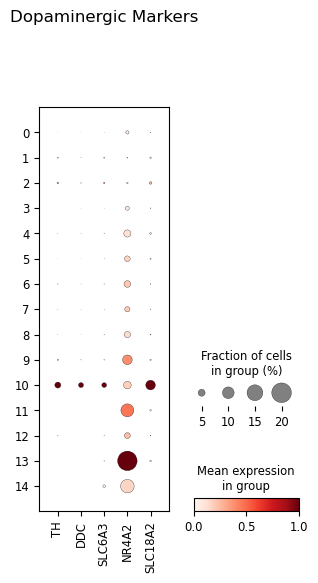

time: 8min 9s (started: 2026-01-08 22:54:49 +00:00)


In [53]:
cluster_key = "leiden_sn_scVI_1.0"
sc.tl.umap(adata_neurons_tmp)
sc.settings.figdir = str( plots_path )
sc.pl.umap(adata_neurons_tmp, color=[cluster_key, "DA_score"], cmap="viridis")

# Dotplot  for DA markers across clusters
sc.pl.dotplot(adata_neurons_tmp, existing_markers, groupby=cluster_key, standard_scale="var", title = "Dopaminergic Markers", save = "DotPlot_DA-markers.png")


/tmp/ipykernel_1553/708037526.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


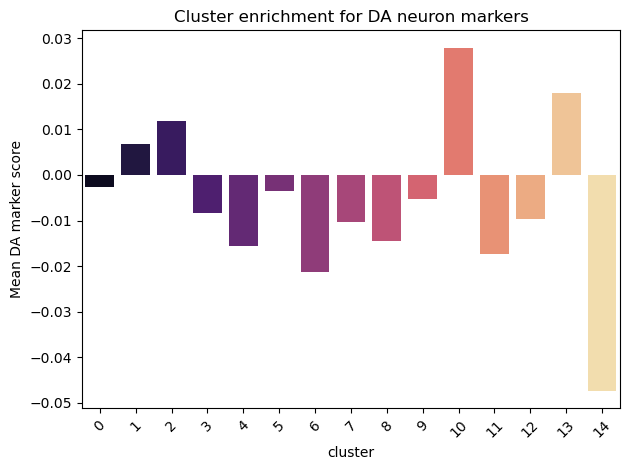

time: 375 ms (started: 2026-01-08 23:02:59 +00:00)


In [54]:
# Group by cluster and compute mean DA_score
cluster_means = (
    adata_neurons_tmp.obs
    .groupby(cluster_key, observed=False )["DA_score"]
    .mean()
    .reset_index()
    .rename(columns={cluster_key: "cluster"})
)


sns.barplot(
    data=cluster_means.reset_index().rename(columns={cluster_key: "cluster"}),
    x="cluster",
    y="DA_score",
    palette="magma"
)
plt.xticks(rotation=45)
plt.ylabel("Mean DA marker score")
plt.title("Cluster enrichment for DA neuron markers")
plt.tight_layout()
plt.show()

In [55]:
print(cluster_means)

   cluster  DA_score
0        0 -0.002650
1        1  0.006847
2        2  0.011807
3        3 -0.008246
4        4 -0.015480
5        5 -0.003479
6        6 -0.021271
7        7 -0.010313
8        8 -0.014452
9        9 -0.005173
10      10  0.027985
11      11 -0.017255
12      12 -0.009577
13      13  0.017890
14      14 -0.047438
time: 2.58 ms (started: 2026-01-08 23:02:59 +00:00)


Text(0.5, 1.0, 'DA score by MapMyCells class')

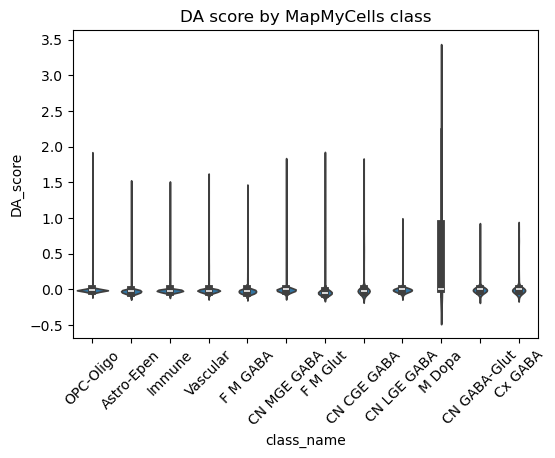

time: 2.22 s (started: 2026-01-08 23:02:59 +00:00)


In [56]:
# binary labels
adata_neurons_tmp.obs["is_DA"] = adata_neurons_tmp.obs["cell_type"] == "Dopaminergic"

# Violin by class
plt.figure(figsize=(6,4))
sns.violinplot(x="class_name", y="DA_score", data=adata_neurons_tmp.obs, order=adata_neurons_tmp.obs["cell_type"].value_counts().index)
plt.xticks(rotation=45)
plt.title("DA score by MapMyCells class")


In [57]:
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, confusion_matrix
# correlation
corr = adata_neurons_tmp.obs[["DA_score","prob"]].dropna().corr().iloc[0,1]
print("Pearson corr (DA_score vs prob):", corr)

# ROC AUC 
y_true = adata_neurons_tmp.obs["is_DA"].astype(int)
y_score = adata_neurons_tmp.obs["DA_score"].fillna(0).values
auc = roc_auc_score(y_true, y_score)
print("ROC AUC (DA_score -> MapMyCells DA):", auc)

# Precision/recall 
score_thresh = np.quantile(adata_neurons_tmp.obs["DA_score"].dropna(), 0.75)
y_pred = (adata_neurons_tmp.obs["DA_score"] >= score_thresh).astype(int)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")
print(f"Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix (rows=true 0/1, cols=pred 0/1):\n", cm)


Pearson corr (DA_score vs prob): -0.06333899139329398
ROC AUC (DA_score -> MapMyCells DA): nan
Precision: 0.000, Recall: 0.000, F1: 0.000
Confusion matrix (rows=true 0/1, cols=pred 0/1):
 [[156026 102479]
 [     0      0]]
time: 223 ms (started: 2026-01-08 23:03:02 +00:00)


/opt/conda/envs/scvi-cells/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/conda/envs/scvi-cells/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 4.3 Refine DA assignment based on DA score and MapMyCells label 

In [58]:
# apply thresholds and create refined column
obs = adata_neurons_tmp.obs
prob_thresh = 0.7
# ensure DA_score and prob columns exist
assert "DA_score" in obs.columns, "DA_score missing"
assert "prob" in obs.columns, "prob missing"
assert "cell_type" in obs.columns, "cell_type missing"

# create boolean masks
is_dopa = obs["cell_type"] == "Dopaminergic"
high_score = obs["DA_score"] >= score_thresh
high_prob = obs["prob"] >= prob_thresh

# new refined label
refined = obs["cell_type"].copy()
# move Dopaminergicto Unknown unless both conditions true
refined.loc[is_dopa & ~(high_score & high_prob)] = "Unknown"
#refining cell_type
adata_neurons_tmp.obs["cell_type_refined"] = refined


time: 6.94 ms (started: 2026-01-08 23:03:08 +00:00)


In [59]:
# refined counts
print("Before refinement")
print(obs["cell_type"].value_counts())
print("\nAfter refinement")
print(adata_neurons_tmp.obs["cell_type_refined"].value_counts())

Before refinement
cell_type
OPC-Oligo        115688
Unknown          107230
Immune            14088
Astrocyte         12527
Vascular           7329
GABAergic           967
Glutamatergic       590
Dopaminergic         86
Name: count, dtype: int64

After refinement
cell_type_refined
OPC-Oligo        115688
Unknown          107235
Immune            14088
Astrocyte         12527
Vascular           7329
GABAergic           967
Glutamatergic       590
Dopaminergic         81
Name: count, dtype: int64
time: 9.55 ms (started: 2026-01-08 23:03:10 +00:00)


In [60]:
# Dotplot and heatmap for DA markers across clusters
marker_table = pd.read_csv( (resources_path/ "example_marker_genes_scMAVERICS.csv") )
marker_genes_xylena = marker_table["official gene symbol"].tolist()

for g in marker_genes_xylena:
    assert g in adata_neurons_tmp.var_names, f"{g} not found in var_names!"
existing_markers_xylena = [g for g in marker_genes_xylena if g in adata_neurons_tmp.var_names]

time: 127 ms (started: 2026-01-08 23:03:19 +00:00)


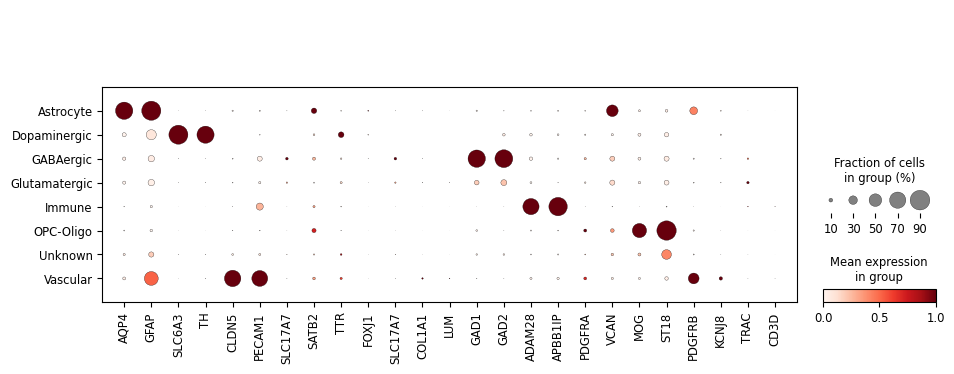

time: 2 s (started: 2026-01-08 23:03:20 +00:00)


In [61]:
# Dotplot and heatmap for DA markers across clusters
sc.settings.figdir = str( plots_path )
sc.pl.dotplot(adata_neurons_tmp, existing_markers_xylena, 
              groupby="cell_type_refined", 
              standard_scale="var", 
             save="_xylena_markers_dotplot.png")

### Compare with Xylena's dotplot

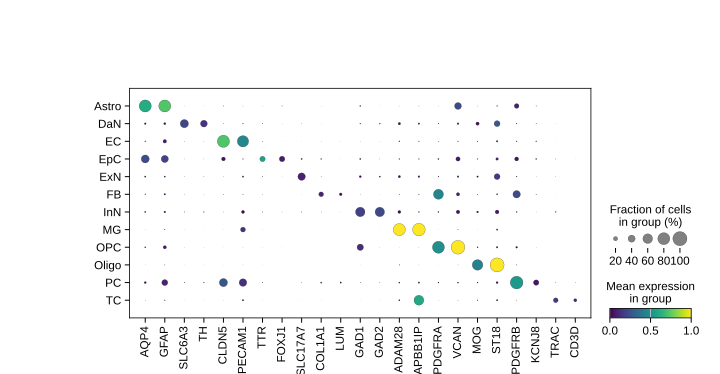

time: 804 ms (started: 2026-01-08 23:03:26 +00:00)


In [62]:
from IPython.display import SVG, display
xylena_dotplot = ( resources_path / "marker_gene_by_cluster_xylena.svg") 
display(SVG(filename=xylena_dotplot))


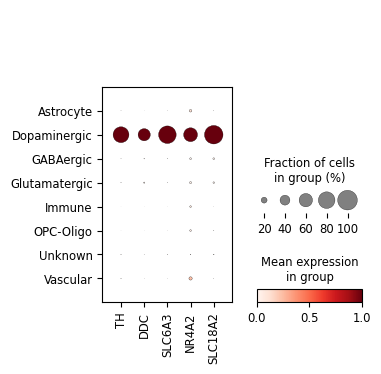

time: 1.72 s (started: 2026-01-08 23:07:32 +00:00)


In [69]:
sc.pl.dotplot(adata_neurons_tmp, existing_markers, 
              groupby="cell_type_refined", standard_scale="var",
             save = "_da_markers_dotplot.png")

In [70]:
proportions = (
    adata_neurons_tmp.obs["cell_type_refined"]
    .value_counts(normalize=True)   # normalize=True → proportions
    .sort_values(ascending=False)
)

proportions


cell_type_refined
OPC-Oligo        0.447527
Unknown          0.414828
Immune           0.054498
Astrocyte        0.048459
Vascular         0.028351
GABAergic        0.003741
Glutamatergic    0.002282
Dopaminergic     0.000313
Name: proportion, dtype: float64

time: 7.91 ms (started: 2026-01-08 23:07:36 +00:00)


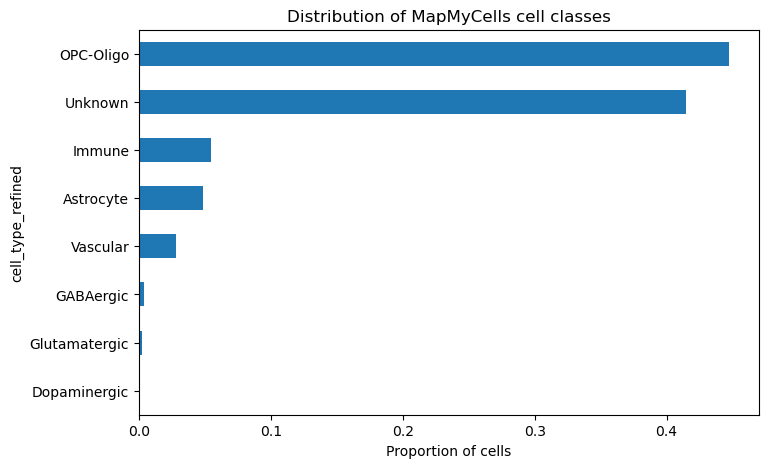

time: 150 ms (started: 2026-01-08 23:07:38 +00:00)


In [71]:
proportions = (
    adata_neurons_tmp.obs["cell_type_refined"]
    .value_counts(normalize=True)
    .sort_values()
)

proportions.plot(kind="barh", figsize=(8,5))
plt.xlabel("Proportion of cells")
plt.title("Distribution of MapMyCells cell classes")
plt.show()


### 4.5 Export refined mapmycells labeling

In [72]:
# saving h5ad
mmc_adata_output_proc_filepath = ( mapmycells_output_dir / 
                             "sn_mapmycells_integrated_processed_output.h5ad")
adata_neurons_tmp.write_h5ad(mmc_adata_output_proc_filepath)

time: 2min 41s (started: 2026-01-08 23:07:43 +00:00)


In [73]:
# saving hvgs_res
hvgs_res_filepath = ( mapmycells_output_dir / 
                             "sn_hvgs_results.csv")
hvgs_res.to_csv(hvgs_res_filepath)

time: 826 ms (started: 2026-01-08 23:10:24 +00:00)


### Prepare data for subset and export

In [75]:
#if starting from here:

adata_output_proc_filepath = ( mapmycells_output_dir / 
                             "sn_mapmycells_integrated_processed_output.h5ad")
adata_neurons_tmp= sc.read_h5ad(adata_output_proc_filepath)

time: 4.65 s (started: 2026-01-08 19:46:47 +00:00)


In [74]:
adata_neurons_tmp.obs["condition_id"].value_counts()

condition_id
PD         132940
Control    125565
Name: count, dtype: int64

time: 7.13 ms (started: 2026-01-08 23:10:25 +00:00)


In [75]:
adata_neurons_tmp.obs["biobank_name"].value_counts()

biobank_name
Banner Sun Health Research Institute    133801
Cambridge Brain Bank                    124704
Name: count, dtype: int64

time: 9.65 ms (started: 2026-01-08 23:10:25 +00:00)


In [76]:
adata_neurons_tmp.obs.columns

Index(['background_fraction', 'cell_probability', 'cell_size',
       'droplet_efficiency', 'n_genes_by_counts', 'total_counts',
       'total_counts_rb', 'pct_counts_rb', 'total_counts_mt', 'pct_counts_mt',
       'doublet_score', 'sample', 'batch', 'team', 'dataset', 'batch_id',
       'S_score', 'G2M_score', 'phase', 'cell_type', 'phenotype', 'rho',
       'prob', 'class_name', 'subclass_name', 'supertype_name', '_scvi_batch',
       '_scvi_labels', 'C_scANVI', 'leiden_res_0.05', 'leiden_res_0.10',
       'leiden_res_0.20', 'leiden_res_0.40', 'brain_region',
       'brain_region_simple', 'case_id', 'condition_id', 'region_level_1',
       'region_level_2', 'dataset_id', 'biobank_name', 'leiden_sn_scVI_1.0',
       'DA_score', 'is_DA', 'cell_type_refined'],
      dtype='object')

time: 5.62 ms (started: 2026-01-08 23:10:25 +00:00)


In [77]:
# assume adata.obs["condition_id"] has values like "control" and "PD"
adata_control = adata_neurons_tmp[adata_neurons_tmp.obs["condition_id"] == "Control"].copy()
adata_case    = adata_neurons_tmp[adata_neurons_tmp.obs["condition_id"] == "PD"].copy()

time: 5.96 s (started: 2026-01-08 23:10:25 +00:00)


In [78]:
# control
control_sum    = sc.get.aggregate(
    adata_control,
    by="cell_type_refined",
    func="sum",
    layer="counts"
)

# PD case
case_sum  = sc.get.aggregate(
    adata_case,
    by="cell_type_refined",
    func="sum",
    layer="counts"
)

#all
all_sum  = sc.get.aggregate(
    adata_neurons_tmp,
    by="cell_type_refined",
    func="sum",
    layer="counts"
)

time: 4.09 s (started: 2026-01-08 23:10:31 +00:00)


In [79]:
# create folders
round1_output_dir = ( output_path / "refined_classes" )
os.makedirs(round1_output_dir, exist_ok=True)

folders = ["case", "control", "all"]
sum_dfs = [control_sum, case_sum, all_sum]

for folder in folders:
    os.makedirs( (round1_output_dir / folder), exist_ok=True)

control_sum.write_h5ad((round1_output_dir / "control" /"sum_counts.h5ad"))

case_sum.write_h5ad((round1_output_dir / "case" /"sum_counts.h5ad"))

all_sum.write_h5ad((round1_output_dir / "all" / "asap-crn_SN_subtyping_v1.0_sum_counts_by_class.csv"))


time: 2.29 s (started: 2026-01-08 23:10:35 +00:00)


In [80]:
df_all_sum = pd.DataFrame(
    all_sum.layers['sum'],
    index=all_sum.obs_names,      # subtypes
    columns=all_sum.var_names     # genes
).T                               # transpose → genes × subtypes

time: 6.23 ms (started: 2026-01-08 23:10:37 +00:00)


In [81]:
# Cornelis provided list of genes
genes_interest = pd.read_csv("/home/jupyter/workspace/ws_files/case_study_01/resources/genes_by_locus.csv")
genes_interest = genes_interest.GENE.tolist()

time: 181 ms (started: 2026-01-08 23:10:37 +00:00)


In [82]:
# subset safely (keeps only genes that exist) 
df_subset = df_all_sum.loc[df_all_sum.index.intersection(genes_interest)] # save to CSV 
df_subset.to_csv(round1_output_dir / "all"/ "asap-crn_SN_genesubset_sum_counts.csv")

missing = [g for g in genes_interest if g not in df_all_sum.index]
len_missing = len(missing)

print("Missing genes:", len_missing)


Missing genes: 963
time: 279 ms (started: 2026-01-08 23:10:37 +00:00)


In [83]:
keep = ["n_genes_by_counts", "total_counts", "total_counts_rb", "pct_counts_rb", "total_counts_mt", "pct_counts_mt",
       "doublet_score", "sample","batch", "team", "condition_id","cell_type_refined","cell_type","class_name", "subclass_name", "supertype_name"  ]
adata_neurons_tmp.obs = adata_neurons_tmp.obs[keep].copy()

time: 18 ms (started: 2026-01-08 23:10:38 +00:00)


In [84]:
adata_neurons_tmp.write_h5ad("/home/jupyter/workspace/ws_files/case_study_01/output_matrices/refined_classes/asap-crn_SN_subtyping_v1.0_processed.h5ad")

time: 2min 38s (started: 2026-01-08 23:10:38 +00:00)


Visualization Summary

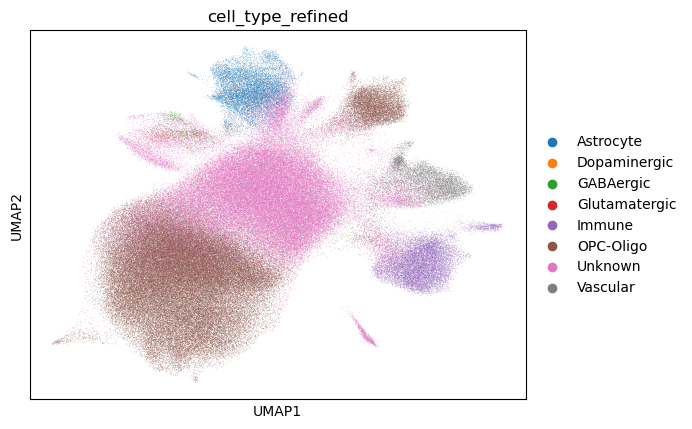

time: 4.67 s (started: 2026-01-08 23:13:17 +00:00)


In [85]:
sc.settings.figdir = "/home/jupyter/workspace/ws_files/case_study_01/output_plots" 
sc.pl.umap( adata_neurons_tmp, 
           color=["cell_type_refined"], 
           save="Fig1_SN_UMAP_cell_type.png" )

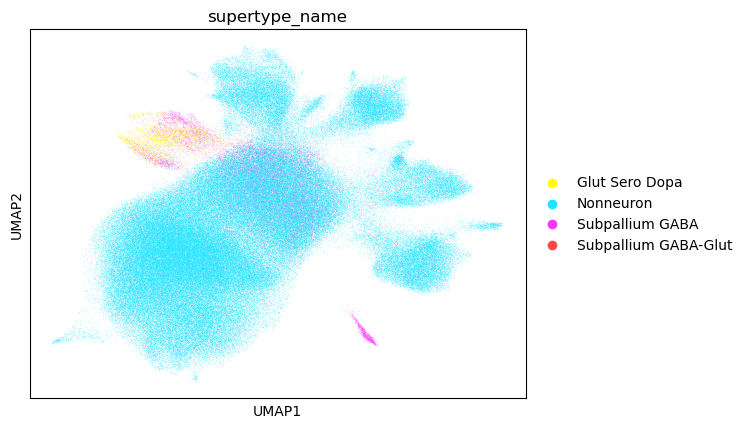

time: 4.55 s (started: 2026-01-08 23:13:21 +00:00)


In [86]:
sc.pl.umap( adata_neurons_tmp, 
           color=["supertype_name"], 
           save="Fig2_SN_UMAP_highlevel_class.png" )



time: 47 s (started: 2026-01-08 23:13:26 +00:00)


In [87]:
# 1. Aggregate mean expression per subtype
mean_agg = sc.get.aggregate(
    adata_neurons_tmp,
    by="cell_type_refined",
    func="mean",
    layer="counts"   # or remove if using adata.X
)

# 2. Put the aggregated matrix into .X so Scanpy can plot it
mean_agg.X = mean_agg.layers["mean"]

existing_markers = [g for g in genes_interest if g in mean_agg.var_names]

# 3. Plot heatmap for a set of genes
sc.pl.heatmap(
    mean_agg,
    var_names=existing_markers,
    groupby="cell_type_refined",
    cmap="viridis",
    show_gene_labels=True,
    save= "Fig3_Heatmap_GenesofInterest.png"
)


In [88]:
import plotly.graph_objects as go
import pandas as pd

def sankey_from_obs(adata, source_col, target_col):
    df = adata.obs[[source_col, target_col]].copy()

    # Count transitions
    flows = df.groupby([source_col, target_col]).size().reset_index(name="value")

    # Build node list
    labels = list(pd.unique(flows[source_col].tolist() + flows[target_col].tolist()))
    label_to_id = {label: i for i, label in enumerate(labels)}

    # Map labels to node IDs
    sources = flows[source_col].map(label_to_id)
    targets = flows[target_col].map(label_to_id)
    values = flows["value"]

    # Build Sankey
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=20,
            thickness=20,
            label=labels
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values
        )
    )])

    fig.update_layout(title_text="Sankey Diagram", font_size=12)
    fig.show()


time: 112 ms (started: 2026-01-08 23:14:13 +00:00)


In [89]:
sankey_from_obs(
    adata_neurons_tmp,
    source_col="class_name",
    target_col="cell_type_refined"
)


/tmp/ipykernel_1553/2604832830.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  flows = df.groupby([source_col, target_col]).size().reset_index(name="value")
/tmp/ipykernel_1553/2604832830.py:11: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  labels = list(pd.unique(flows[source_col].tolist() + flows[target_col].tolist()))


time: 9.26 s (started: 2026-01-08 23:14:13 +00:00)


/tmp/ipykernel_1553/2604832830.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1553/2604832830.py:11: FutureWarning:

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



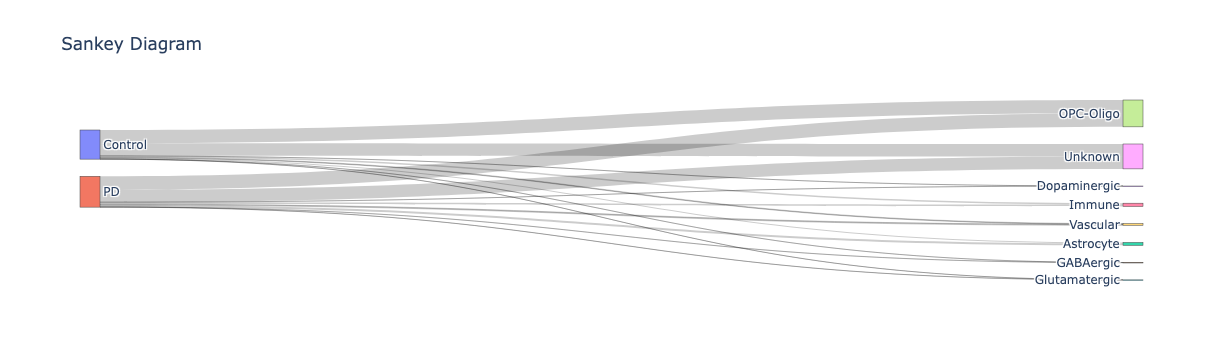

time: 29.7 ms (started: 2026-01-08 23:14:22 +00:00)


In [90]:
sankey_from_obs(
    adata_neurons_tmp,
    source_col="condition_id",
    target_col="cell_type_refined"
)


In [93]:
#if you have a scanvi label - 3 layered Sankey
# df = adata_neurons_tmp.obs[[
#     "class_name",
#     "cell_type_refined",
#     "scanvi_label"
# ]].copy()


# layers = ["class_name", "cell_type_refined", "scanvi_label"]

# labels = pd.unique(df[layers].values.ravel())
# label_to_id = {label: i for i, label in enumerate(labels)}

# links = []

# for src_col, tgt_col in zip(layers[:-1], layers[1:]):
#     grouped = df.groupby([src_col, tgt_col]).size().reset_index(name="count")
    
#     for _, row in grouped.iterrows():
#         links.append({
#             "source": label_to_id[row[src_col]],
#             "target": label_to_id[row[tgt_col]],
#             "value": row["count"]
#         })

# fig = go.Figure(data=[go.Sankey(
#     node=dict(
#         pad=20,
#         thickness=20,
#         label=labels
#     ),
#     link=dict(
#         source=[l["source"] for l in links],
#         target=[l["target"] for l in links],
#         value=[l["value"] for l in links]
#     )
# )])

# fig.update_layout(
#     title_text="3‑Layer Sankey: MMC → MMC‑hiqual+Unknown → SCANVI",
#     font_size=12
# )

# fig.show()


time: 791 μs (started: 2026-01-08 23:15:37 +00:00)


# stop here or optimize further

## 5. Train scANVI

- decision forks:
    - using HVGs or complete gene set for scANVI (USING HVG FOR SPEED) --> KEEPS DYING for cpu, running in GPU
    - Training vs fine-tuning previous scANVI model; training due to different granularity of cell composition.
    - balancing seeds across classes, did not do because the smallest cluster is ~100 cells 

In [5]:
# if starting here
# mmc_adata_output_proc_filepath = ( mapmycells_output_dir / 
#                              "sn_mapmycells_integrated_processed_output.h5ad")
# adata_neurons_tmp = sc.read_h5ad(mmc_adata_output_proc_filepath)
# hvgs_res_filepath = ( mapmycells_output_dir / 
#                              "sn_hvgs_results.csv")
# hvgs_res = pd.read_csv(hvgs_res_filepath, index_col = 0)

In [6]:
#CONFIG
BATCH_KEY = "sample"  
CLUSTER_KEY =  "leiden_sn_scVI_1.0"
NEW_LABELS_COL = "mmc_class_refined_2" 
EXTERNAL_LABELS_COL = "mmc_class"
UNLABELED_TOKEN = "Unknown"

# Marker panels
DA_MARKERS = ["TH","DDC","SLC6A3","NR4A2","SLC18A2"]

In [7]:
# # Balance seeds across classes
# rng = np.random.default_rng(0)
# classes = adata_neurons_tmp.obs.mmc_class_refined_2.unique().tolist()
# adata_neurons_tmp.obs[NEW_LABELS_COL] = adata_neurons_tmp.obs.mmc_class_refined_2
# counts = adata_neurons_tmp.obs[NEW_LABELS_COL].value_counts()
# n_min = min(counts.get(c,0) for c in classes if counts.get(c,0)>0)
# adata_neurons_tmp.obs["subsample_status"] = "not_subsampled"
# for c in classes:
#     idx = np.where(adata_neurons_tmp.obs[NEW_LABELS_COL].values == c)[0]
#     if len(idx) > n_min and n_min > 0:
#         keep = rng.choice(idx, size=n_min, replace=False)
#         drop = np.setdiff1d(idx, keep)
#         adata_neurons_tmp.obs.iloc[keep, adata_neurons_tmp.obs.columns.get_loc("subsample_status")] = f"kept_{c}"
#         adata_neurons_tmp.obs.iloc[drop, adata_neurons_tmp.obs.columns.get_loc("subsample_status")] = f"dropped_{c}"
#         adata_neurons_tmp.obs.iloc[drop, adata_neurons_tmp.obs.columns.get_loc(NEW_LABELS_COL)] = UNLABELED_TOKEN

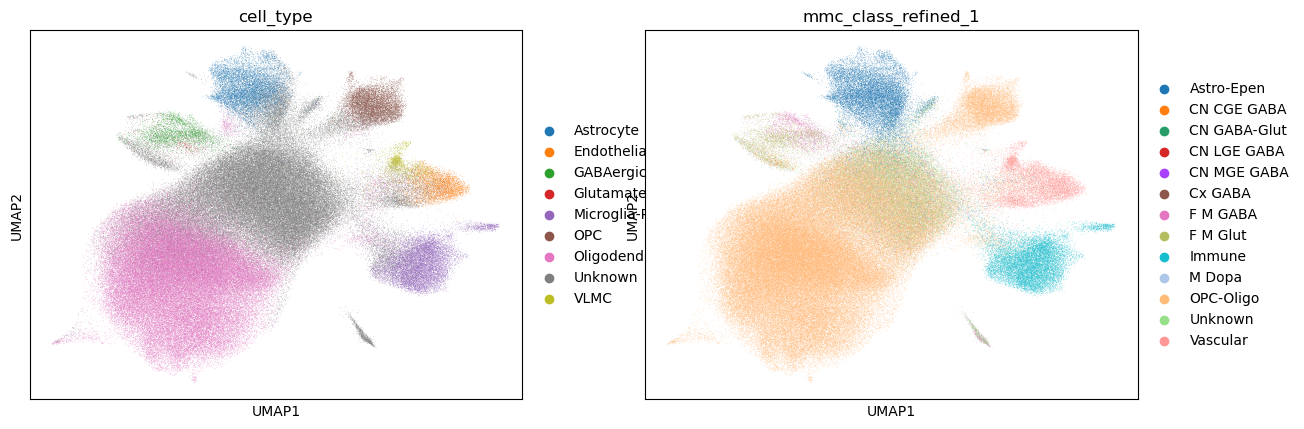

In [8]:
sc.pl.umap(adata_neurons_tmp, color=[ "cell_type", "mmc_class_refined_1"], cmap="viridis")

In [9]:
if hasattr(hvgs_res, "index"):
    hvgs = hvgs_res.index[hvgs_res["highly_variable"]].tolist() if "highly_variable" in hvgs_res.columns else hvgs_res.index.tolist()
else:
    hvgs = list(hvgs_res)

# 2. add marker genes (ensure they are in the same namespace as adata.var_names)
marker_genes = ["TH","DDC","SLC6A3","SLC18A2","NR4A2"]  

# keep only genes present in adata
hvgs = [g for g in hvgs if g in adata_neurons_tmp.var_names]
markers_present = [g for g in marker_genes if g in adata_neurons_tmp.var_names]
gene_set = list(dict.fromkeys(hvgs + markers_present))  # preserve order, dedupe

print(f"HVGS found: {len(hvgs)}; markers present: {len(markers_present)}; final gene set: {len(gene_set)}")

HVGS found: 3000; markers present: 5; final gene set: 3004


In [10]:
adata_hvg = adata_neurons_tmp[:, gene_set].copy()

# sanity checks
assert all(g in adata_hvg.var_names for g in gene_set)
print("adata_hvg shape:", adata_hvg.shape)
# ensure counts layer exists
if "counts" not in adata_hvg.layers:
    raise ValueError("counts layer missing; scVI/scANVI expects raw counts in a layer named 'counts'")


adata_hvg shape: (258505, 3004)


# Run on GPU Instance to train

In [13]:
# # Training scANVI model due to cell composition and specificity to SN 
# scvi.model.SCANVI.setup_anndata(
#     adata_hvg,
#     layer="counts",
#     batch_key=BATCH_KEY, #sample
#     labels_key=NEW_LABELS_COL,
#     unlabeled_category=UNLABELED_TOKEN
# )

# scanvi_model = scvi.model.SCANVI(adata_hvg,
#     UNLABELED_TOKEN,
#     dispersion = "gene-cell",
#     gene_likelihood = "zinb",
#     n_latent = 10,
#     n_layers =2
# )

# scanvi_model.train(
#     max_epochs=100,
#     early_stopping=True,
#     accelerator="gpu",
#     devices = "1",
#     early_stopping_patience=5,
#     check_val_every_n_epoch=10
# )

# adata_hvg.obs["scanvi_labels"] = scanvi_model.predict()
# probas = scanvi_model.predict(soft=True)
# adata_hvg.obsm["scanvi_probas"] = probas
# adata_hvg.obs["scanvi_confidence"] = probas.max(axis=1)
#os.makedirs(scanvi_model_path, exist_ok=True)
#scanvi_model.save(scanvi_model_path, overwrite=True)

INFO     Training for 100 epochs.                                                                                  


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/opt/conda/envs/scvi-cells/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/opt/conda/envs/scvi-cells/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Epoch 100/100: 100%|██████████| 100/100 [1:37:42<00:00, 58.49s/it, v_num=1, train_loss_step=1.14e+3, train_loss_epoch=1.01e+3]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [1:37:42<00:00, 58.63s/it, v_num=1, train_loss_step=1.14e+3, train_loss_epoch=1.01e+3]


In [12]:
# reload the model
from scvi.model import SCANVI
scanvi_model_path = ( local_data_path / "scanvi/ sn_scanvi_model")
scanvi_model = SCANVI.load(scanvi_model_path, adata=adata_hvg)

INFO     File /home/jupyter/workspace/ws_files/case_study_01/scanvi/ sn_scanvi_model/model.pt already downloaded   


<Axes: xlabel='epoch'>

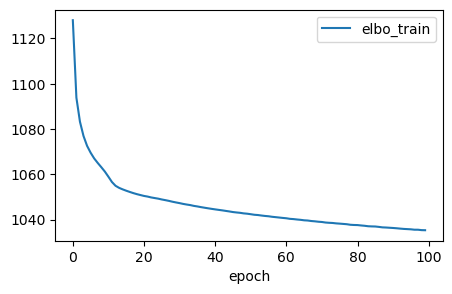

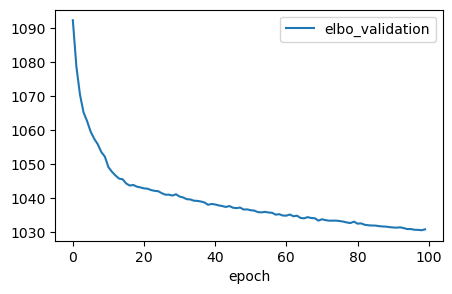

In [13]:
scanvi_model.history["elbo_train"].plot(figsize=(5,3)); scanvi_model.history["elbo_validation"].plot(figsize=(5,3))

In [14]:
# After training
hist = scanvi_model.history
print({k: hist[k][-1:] for k in ["elbo_train", "elbo_validation", "train_classification_loss","train_accuracy","train_f1_score"]})

# If you trained with validation:
# scanvi_model.train(..., check_val_every_n_epoch=10)
for k in ["elbo_validation", "elbo_validation","validation_classification_loss","validation_accuracy","validation_f1_score"]:
    if k in hist:
        print(k, hist[k][-1:])


{'elbo_train':         elbo_train
epoch             
99     1035.265381, 'elbo_validation':       elbo_validation
epoch                
99        1030.889404, 'train_classification_loss':       train_classification_loss
epoch                          
99                      0.01448, 'train_accuracy':       train_accuracy
epoch               
99          0.995205, 'train_f1_score':       train_f1_score
epoch               
99          0.995205}
elbo_validation       elbo_validation
epoch                
99        1030.889404
elbo_validation       elbo_validation
epoch                
99        1030.889404
validation_classification_loss       validation_classification_loss
epoch                               
99                           0.57199
validation_accuracy       validation_accuracy
epoch                    
99               0.802695
validation_f1_score       validation_f1_score
epoch                    
99               0.802695


{'elbo_train':         elbo_train
epoch             
99     1035.265381, 'elbo_validation':       elbo_validation
epoch                
99        1030.889404}


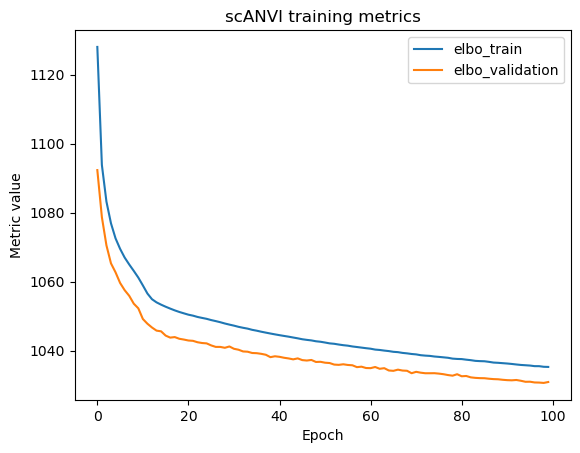

In [15]:

hist = scanvi_model.history
print({k: hist[k][-1:] for k in ["elbo_train","elbo_validation"]})

for k in ["elbo_train","elbo_validation"]:
    if k in hist:
        plt.plot(hist[k], label=k)

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("scANVI training metrics")
plt.show()


could've done a few more epochs, but it doesn't look terrible

In [20]:
# Predict labels with scANVI
pred_labels = scanvi_model.predict()
#save
adata_hvg.obs["scanvi_labels"] = pred_labels

# extract confidence scores
probas = scanvi_model.predict(soft=True)
adata_hvg.obsm["scanvi_probas"] = probas
adata_hvg.obs["scanvi_confidence"] = probas.max(axis=1)

# Thresholding
thr = 0.5
adata_hvg.obs["scanvi_labels_conf"] = np.where(adata_hvg.obs["scanvi_confidence"] >= thr,
                                              scanvi_model.predict(),
                                              "Unknown")

In [22]:
adata_hvg.obs["scanvi_labels_conf"].value_counts()

scanvi_labels_conf
OPC-Oligo       138397
CN MGE GABA      63142
Astro-Epen       19849
Immune           16324
Vascular         11079
F M Glut          5593
F M GABA          3765
Unknown            320
CN GABA-Glut        30
Cx GABA              6
Name: count, dtype: int64

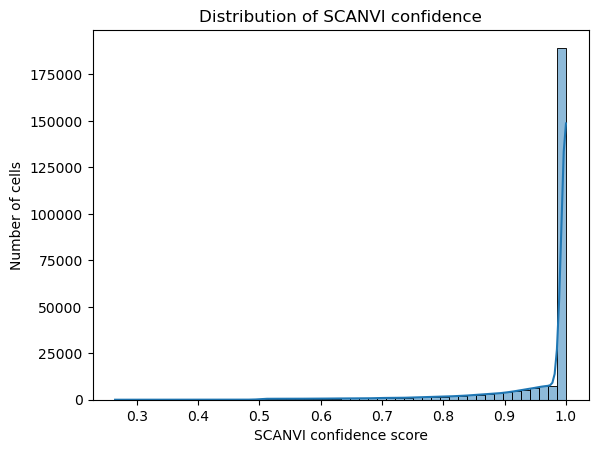

In [17]:
sns.histplot(adata_hvg.obs["scanvi_confidence"], bins=50, kde=True)
plt.xlabel("SCANVI confidence score")
plt.ylabel("Number of cells")
plt.title("Distribution of SCANVI confidence")
plt.show()


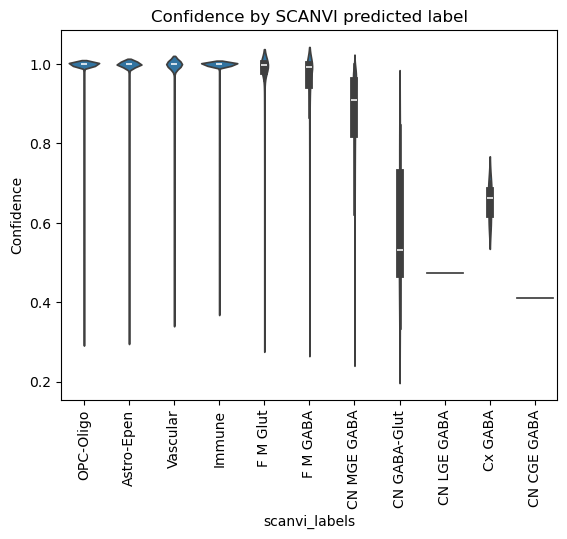

In [23]:
sns.violinplot(x=adata_hvg.obs["scanvi_labels"], 
               y=adata_hvg.obs["scanvi_confidence"])
plt.xticks(rotation=90)
plt.ylabel("Confidence")
plt.title("Confidence by SCANVI predicted label")
plt.show()


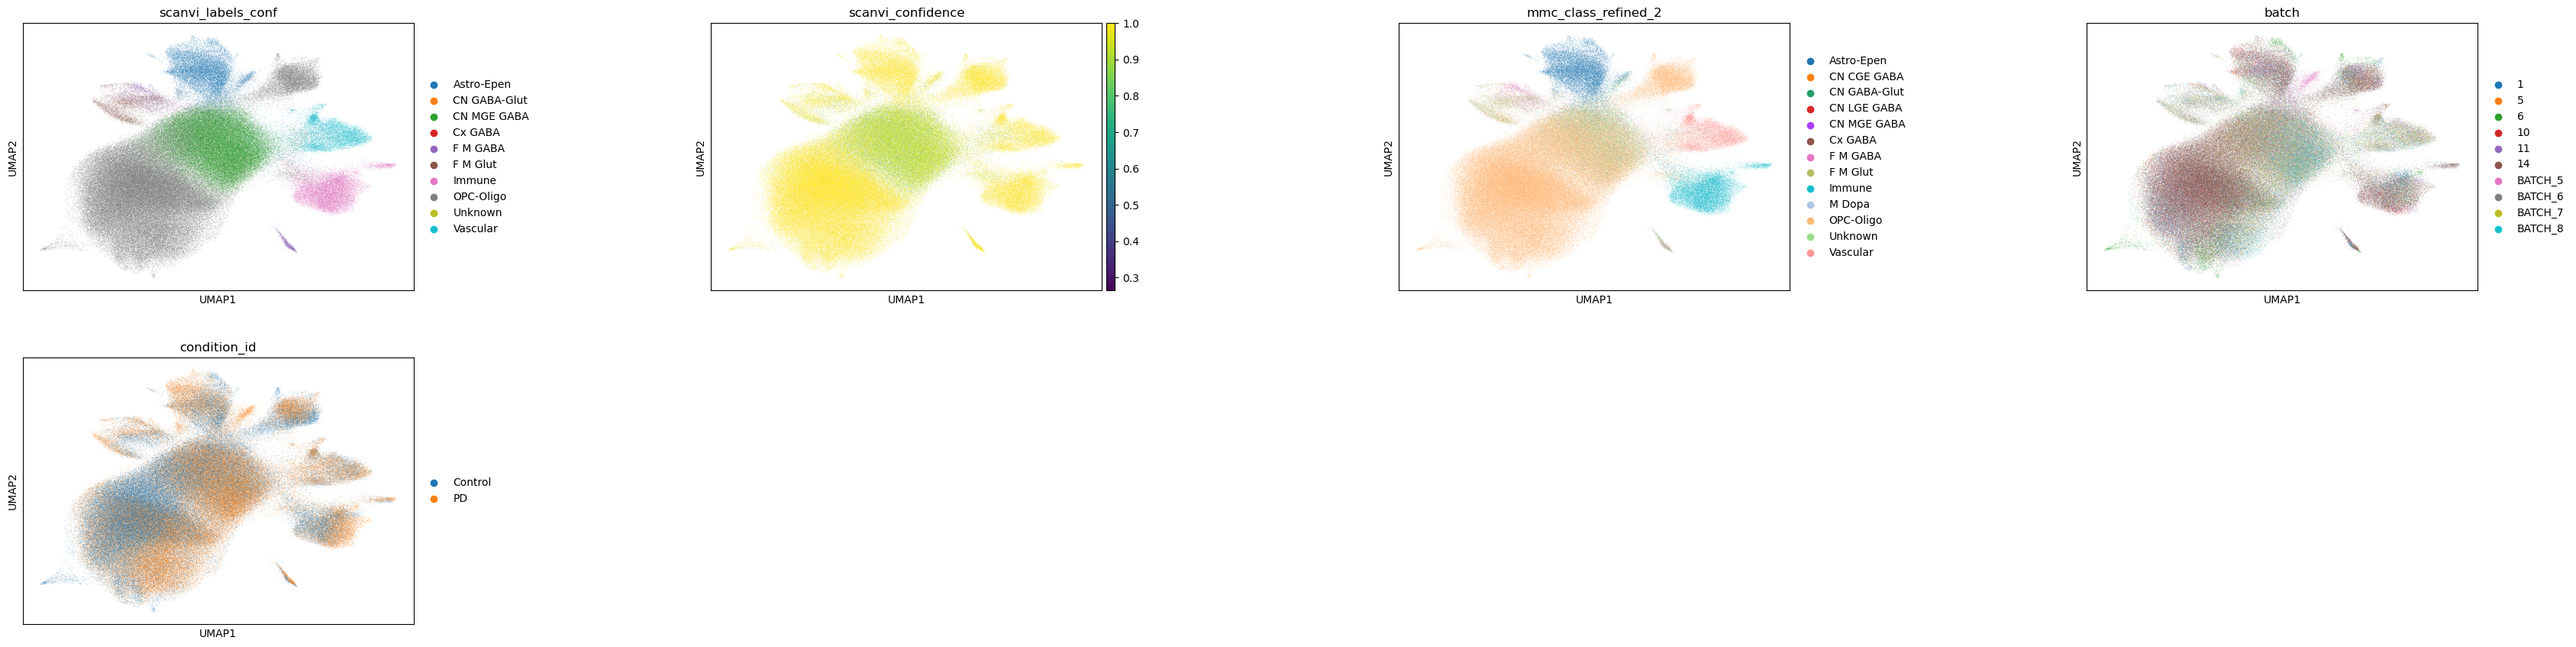

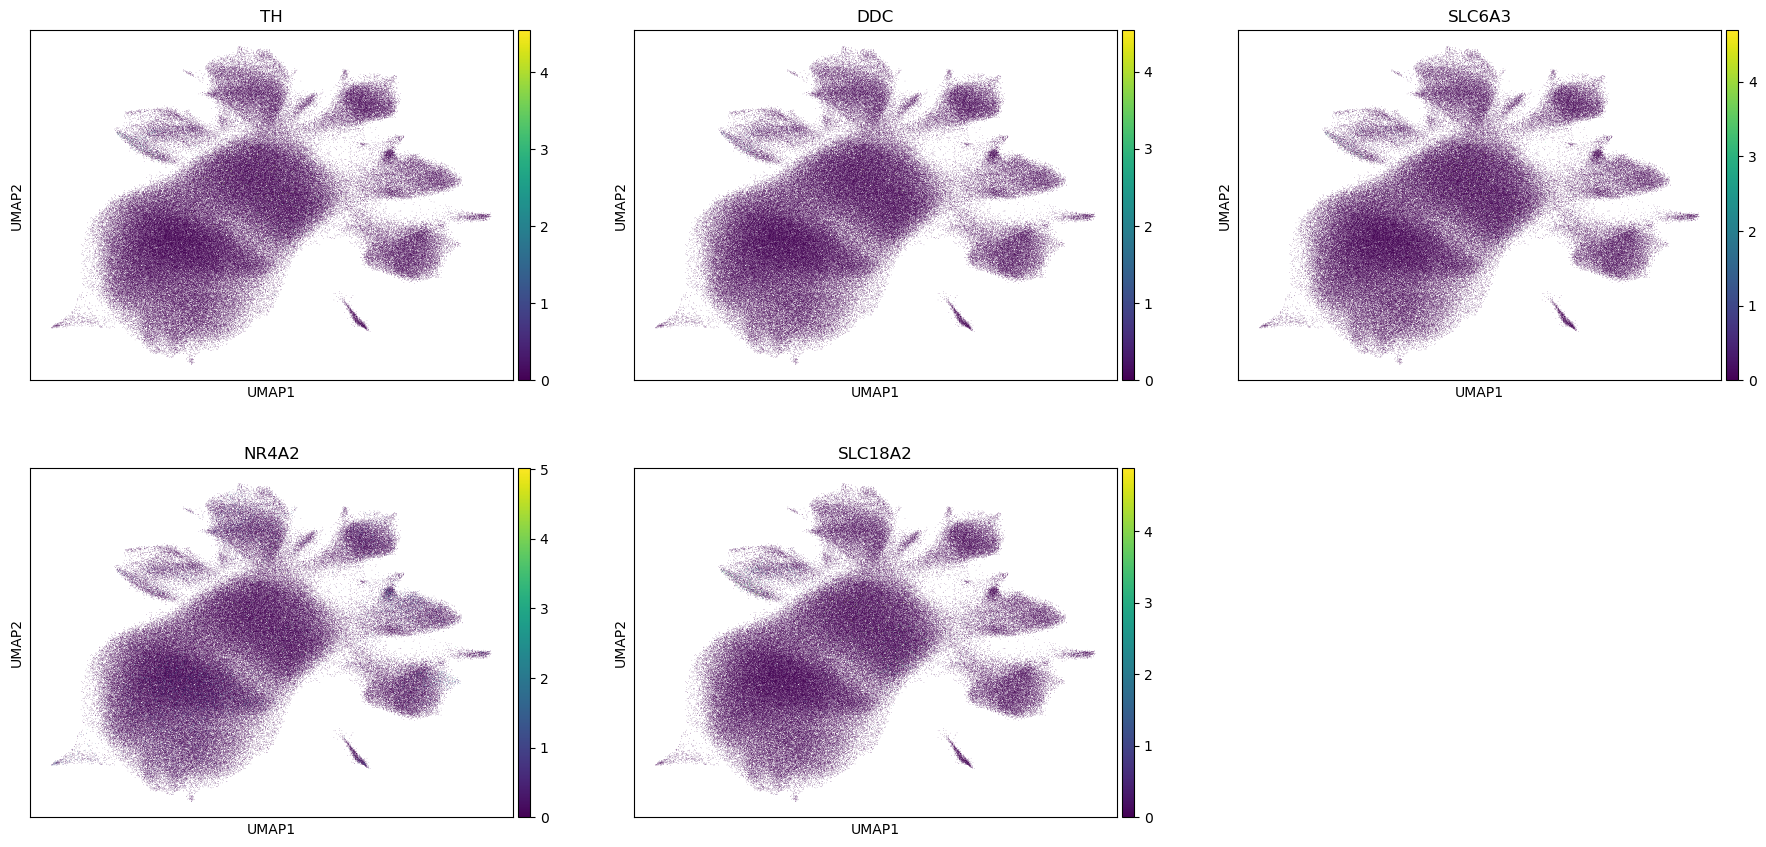

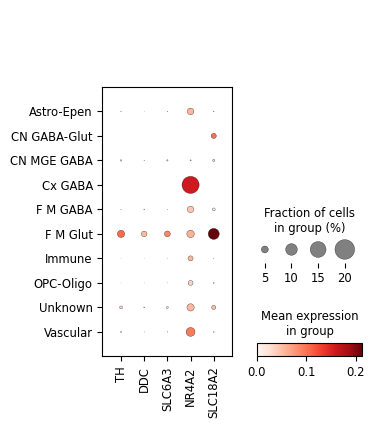

In [27]:
sc.pl.umap(adata_hvg, color=["scanvi_labels_conf","scanvi_confidence", "mmc_class_refined_2", "batch","condition_id"], wspace=0.6)

# Canonical panels
DA_MARKERS = ["TH","DDC","SLC6A3","NR4A2","SLC18A2"]

sc.pl.umap(adata_hvg, color=DA_MARKERS, ncols=3)
sc.pl.dotplot(adata_hvg, var_names=DA_MARKERS, groupby="scanvi_labels_conf")


### scANVI collapsed DA neuron cell type, so round1 cell type annotation is probably enough until we can get more cells or refine the scANVI model more. 

In [28]:
# import scib

# # --- CONFIG ---
# latent_key = "X_scVI"          # latent representation
# label_key  = "scanvi_labels"   # predicted labels
# batch_key  = "sample"           # batch/sample column

# # --- Run scIB metrics ---
# results = {}

# # Batch mixing
# results["kBET"] = scib.metrics.kBET(
#     adata,
#     batch_key=batch_key,
#     label_key=label_key,
#     type_="knn",
#     subsample=0.5
# )

# results["LISI_batch"] = scib.metrics.lisi(
#     adata,
#     batch_key=batch_key,
#     type_="batch",
#     n_neighbors=90
# )

# # Biological conservation
# results["ARI"] = scib.metrics.ari(
#     adata,
#     label_key=label_key,
#     cluster_key="leiden_sn_scVI"  # or any clustering you ran
# )

# results["NMI"] = scib.metrics.nmi(
#     adata,
#     label_key=label_key,
#     cluster_key="leiden_sn_scVI"
# )

# results["Silhouette"] = scib.metrics.silhouette(
#     adata,
#     label_key=label_key,
#     embed=latent_key
# )

# # --- Summarize ---
# df_results = pd.DataFrame.from_dict(results, orient="index", columns=["score"])
# print(df_results)
